<a href="https://colab.research.google.com/github/gbaranaos/iele756-region-4/blob/main/Tarea3_comuna_13101_Santiago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Tarea 3: Cross-Dataset Ecological Modeling
**Curso:** IELE756 – Preparación y Análisis de Datos  
**Alumno:** Guillermo Barañao

**Fecha:** 03 de Mayo 2026  
**Comuna asignada:** Santiago (`13101`)  



In [ ]:
# ===============================
# TAREA 3 — SETUP INICIAL
# ===============================

import os
import glob
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Carpeta actual:", os.getcwd())
print("Archivos disponibles:")
print(os.listdir())

Carpeta actual: /content
Archivos disponibles:
['.config', 'eno_team19.csv', 'eno_team05.csv', 'eno_team07.csv', 'eno_team04.csv', 'grd_team17.csv', 'eno_team10.csv', 'grd_team18.csv', 'census_team07.csv', 'census_team11.csv', 'grd_team05.csv', 'eno_team09.csv', 'grd_team15.csv', 'census_team09.csv', 'census_team16.csv', 'census_team03.csv', 'eno_team16.csv', 'grd_team04.csv', 'grd_team21.csv', 'grd_team08.csv', 'eno_team02.csv', 'eno_team01.csv', 'grd_team19.csv', 'comunas.CPG', 'eno_team18.csv', 'grd_team13.csv', 'census_team15.csv', 'eno_team06.csv', 'grd_team11.csv', 'eno_team03.csv', 'census_team18.csv', 'grd_team06.csv', 'census_team06.csv', 'comunas (1).shp', 'census_team19.csv', 'grd_team02.csv', 'census_team02.csv', '.ipynb_checkpoints', 'census_team08.csv', 'grd_team09.csv', 'comunas.dbf', 'grd_team16.csv', 'census_team10.csv', 'eno_team08.csv', 'comunas.prj', 'census_team20.csv', 'grd_team01.csv', 'comunas (1).sbx', 'census_team05.csv', 'eno_team21.csv', 'grd_team10.csv', 'c

In [ ]:
# ===============================
# BUSCAR ARCHIVOS CSV
# ===============================

search_paths = ["*.csv", "/mnt/data/*.csv"]

all_csv_files = []
for path in search_paths:
    all_csv_files.extend(glob.glob(path))

all_csv_files = sorted(list(set(all_csv_files)))

print("CSV encontrados:")
for f in all_csv_files:
    print(f)

census_files = sorted([f for f in all_csv_files if os.path.basename(f).startswith("census_team")])
eno_files = sorted([f for f in all_csv_files if os.path.basename(f).startswith("eno_team")])
grd_files = sorted([f for f in all_csv_files if os.path.basename(f).startswith("grd_team")])

print("\nCantidad de archivos:")
print("Census:", len(census_files))
print("ENO:", len(eno_files))
print("GRD:", len(grd_files))

print("\nCensus files:", census_files)
print("ENO files:", eno_files)
print("GRD files:", grd_files)

CSV encontrados:
census_team01.csv
census_team02.csv
census_team03.csv
census_team04.csv
census_team05.csv
census_team06.csv
census_team07.csv
census_team08.csv
census_team09.csv
census_team10.csv
census_team11.csv
census_team12.csv
census_team13.csv
census_team14.csv
census_team15.csv
census_team16.csv
census_team17.csv
census_team18.csv
census_team19.csv
census_team20.csv
census_team21.csv
eno_team01.csv
eno_team02.csv
eno_team03.csv
eno_team04.csv
eno_team05.csv
eno_team06.csv
eno_team07.csv
eno_team08.csv
eno_team09.csv
eno_team10.csv
eno_team11.csv
eno_team12.csv
eno_team13.csv
eno_team14.csv
eno_team15.csv
eno_team16.csv
eno_team17.csv
eno_team18.csv
eno_team19.csv
eno_team20.csv
eno_team21.csv
grd_team01.csv
grd_team02.csv
grd_team03.csv
grd_team04.csv
grd_team05.csv
grd_team06.csv
grd_team07.csv
grd_team08.csv
grd_team09.csv
grd_team10.csv
grd_team11.csv
grd_team12.csv
grd_team13.csv
grd_team14.csv
grd_team15.csv
grd_team16.csv
grd_team17.csv
grd_team18.csv
grd_team19.csv
grd_t

In [ ]:
# ===============================
# CARGAR Y CONCATENAR
# ===============================

if len(census_files) == 0:
    raise FileNotFoundError("No se encontraron archivos census_team*.csv")

if len(eno_files) == 0:
    raise FileNotFoundError("No se encontraron archivos eno_team*.csv")

if len(grd_files) == 0:
    raise FileNotFoundError("No se encontraron archivos grd_team*.csv")

census_master_raw = pd.concat(
    [pd.read_csv(f) for f in census_files],
    ignore_index=True
)

eno_master_raw = pd.concat(
    [pd.read_csv(f) for f in eno_files],
    ignore_index=True
)

grd_master_raw = pd.concat(
    [pd.read_csv(f) for f in grd_files],
    ignore_index=True
)

print("Census raw:", census_master_raw.shape)
print("ENO raw:", eno_master_raw.shape)
print("GRD raw:", grd_master_raw.shape)

display(census_master_raw.head())
display(eno_master_raw.head())
display(grd_master_raw.head())

Census raw: (54, 13)
ENO raw: (54, 8)
GRD raw: (54, 13)


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13111,La Granja,112022.0,101705.0,9550.0,8.525111,39.0,32.0,10.856734,12.150499,59.357184,72.139429,49.864212
1,13118,Macul,123800.0,105336.0,17497.0,14.133279,39.0,35.0,13.336334,14.598976,69.140360,81.189070,44.132816
2,13131,San Ramón,76002.0,69248.0,6214.0,8.176101,40.0,32.0,10.520867,11.916823,60.325979,73.826821,49.669161
3,13110,La Florida,374836.0,335340.0,36685.0,9.786947,38.0,34.0,12.846742,13.965309,65.992957,78.785794,46.806252
4,13109,La Reina,103157.0,82209.0,19762.0,19.380000,37.0,32.0,12.910000,13.560000,67.500000,78.900000,44.800000


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13111,La Granja,943,454,108,381,VIH | Parotiditis | Coqueluche,84.179893
1,13118,Macul,890,405,110,375,VIH | Parotiditis | Coqueluche,71.890145
2,13131,San Ramón,687,359,54,274,VIH | Parotiditis | Coqueluche,90.392358
3,13110,La Florida,2128,1539,342,247,VIH | Sifilis | Parotiditis,56.771495
4,13109,La Reina,714,333,149,232,VIH | Parotiditis | Coqueluche,69.210000


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13111,La Granja,14803,13943,860,5.809633,5.393569,5.440436,4.633721,1.482875,2.526515,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1321.436861
1,13118,Macul,13343,12128,1215,9.105898,5.520947,5.670679,4.026337,1.569962,3.440006,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1077.786753
2,13131,San Ramón,11743,10986,757,6.446394,4.966448,5.019843,4.191546,1.453802,2.214085,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1545.090919
3,13110,La Florida,49846,46736,3110,6.239217,6.002898,6.132362,4.133389,1.403522,2.999238,H25.9 | K80.2 | Z51.1,1329.808236
4,13109,La Reina,5004,4692,312,6.240000,5.380000,5.480000,3.850000,1.382000,2.618000,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,485.090000


In [ ]:
# ===============================
# CARGAR Y CONCATENAR
# ===============================

if len(census_files) == 0:
    raise FileNotFoundError("No se encontraron archivos census_team*.csv")

if len(eno_files) == 0:
    raise FileNotFoundError("No se encontraron archivos eno_team*.csv")

if len(grd_files) == 0:
    raise FileNotFoundError("No se encontraron archivos grd_team*.csv")

census_master_raw = pd.concat(
    [pd.read_csv(f) for f in census_files],
    ignore_index=True
)

eno_master_raw = pd.concat(
    [pd.read_csv(f) for f in eno_files],
    ignore_index=True
)

grd_master_raw = pd.concat(
    [pd.read_csv(f) for f in grd_files],
    ignore_index=True
)

print("Census raw:", census_master_raw.shape)
print("ENO raw:", eno_master_raw.shape)
print("GRD raw:", grd_master_raw.shape)

display(census_master_raw.head())
display(eno_master_raw.head())
display(grd_master_raw.head())

Census raw: (54, 13)
ENO raw: (54, 8)
GRD raw: (54, 13)


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13111,La Granja,112022.0,101705.0,9550.0,8.525111,39.0,32.0,10.856734,12.150499,59.357184,72.139429,49.864212
1,13118,Macul,123800.0,105336.0,17497.0,14.133279,39.0,35.0,13.336334,14.598976,69.140360,81.189070,44.132816
2,13131,San Ramón,76002.0,69248.0,6214.0,8.176101,40.0,32.0,10.520867,11.916823,60.325979,73.826821,49.669161
3,13110,La Florida,374836.0,335340.0,36685.0,9.786947,38.0,34.0,12.846742,13.965309,65.992957,78.785794,46.806252
4,13109,La Reina,103157.0,82209.0,19762.0,19.380000,37.0,32.0,12.910000,13.560000,67.500000,78.900000,44.800000


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13111,La Granja,943,454,108,381,VIH | Parotiditis | Coqueluche,84.179893
1,13118,Macul,890,405,110,375,VIH | Parotiditis | Coqueluche,71.890145
2,13131,San Ramón,687,359,54,274,VIH | Parotiditis | Coqueluche,90.392358
3,13110,La Florida,2128,1539,342,247,VIH | Sifilis | Parotiditis,56.771495
4,13109,La Reina,714,333,149,232,VIH | Parotiditis | Coqueluche,69.210000


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13111,La Granja,14803,13943,860,5.809633,5.393569,5.440436,4.633721,1.482875,2.526515,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1321.436861
1,13118,Macul,13343,12128,1215,9.105898,5.520947,5.670679,4.026337,1.569962,3.440006,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1077.786753
2,13131,San Ramón,11743,10986,757,6.446394,4.966448,5.019843,4.191546,1.453802,2.214085,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1545.090919
3,13110,La Florida,49846,46736,3110,6.239217,6.002898,6.132362,4.133389,1.403522,2.999238,H25.9 | K80.2 | Z51.1,1329.808236
4,13109,La Reina,5004,4692,312,6.240000,5.380000,5.480000,3.850000,1.382000,2.618000,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,485.090000


In [ ]:
# ===============================
# REVISAR COLUMNAS
# ===============================

print("Columnas Census:")
print(census_master_raw.columns.tolist())

print("\nColumnas ENO:")
print(eno_master_raw.columns.tolist())

print("\nColumnas GRD:")
print(grd_master_raw.columns.tolist())

Columnas Census:
['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio']

Columnas ENO:
['codigo_comuna', 'nombre_comuna', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k']

Columnas GRD:
['codigo_comuna', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


In [ ]:
# ===============================
# SANITY CHECKS
# ===============================

def check_master(df, name):
    print(f"\n{name}")
    print("Filas:", len(df))
    print("Columnas:", df.shape[1])

    if "codigo_comuna" in df.columns:
        print("Comunas únicas:", df["codigo_comuna"].nunique())
        print("Duplicados por codigo_comuna:", df["codigo_comuna"].duplicated().sum())
    else:
        print("ERROR: no existe codigo_comuna")

check_master(census_master_raw, "CENSUS")
check_master(eno_master_raw, "ENO")
check_master(grd_master_raw, "GRD")


CENSUS
Filas: 54
Columnas: 13
Comunas únicas: 51
Duplicados por codigo_comuna: 3

ENO
Filas: 54
Columnas: 8
Comunas únicas: 51
Duplicados por codigo_comuna: 3

GRD
Filas: 54
Columnas: 13
Comunas únicas: 51
Duplicados por codigo_comuna: 3


In [ ]:
# ===============================
# LIMPIAR CODIGO_COMUNA
# ===============================

def clean_codigo_comuna(df):
    df = df.copy()
    df["codigo_comuna"] = pd.to_numeric(df["codigo_comuna"], errors="coerce")
    return df

census_master_raw = clean_codigo_comuna(census_master_raw)
eno_master_raw = clean_codigo_comuna(eno_master_raw)
grd_master_raw = clean_codigo_comuna(grd_master_raw)

print("Códigos comuna nulos:")
print("Census:", census_master_raw["codigo_comuna"].isna().sum())
print("ENO:", eno_master_raw["codigo_comuna"].isna().sum())
print("GRD:", grd_master_raw["codigo_comuna"].isna().sum())

Códigos comuna nulos:
Census: 0
ENO: 0
GRD: 0


In [ ]:
# ===============================
# ELIMINAR DUPLICADOS ROBUSTAMENTE
# ===============================

def keep_best_duplicate(df, key="codigo_comuna"):
    df = df.copy()
    df["_non_null_count"] = df.notna().sum(axis=1)

    df = (
        df.sort_values([key, "_non_null_count"], ascending=[True, False])
          .drop_duplicates(subset=key, keep="first")
          .drop(columns="_non_null_count")
    )

    return df

census_master = keep_best_duplicate(census_master_raw)
eno_master = keep_best_duplicate(eno_master_raw)
grd_master = keep_best_duplicate(grd_master_raw)

print("Después de eliminar duplicados:")
print("Census:", census_master.shape, "comunas:", census_master["codigo_comuna"].nunique())
print("ENO:", eno_master.shape, "comunas:", eno_master["codigo_comuna"].nunique())
print("GRD:", grd_master.shape, "comunas:", grd_master["codigo_comuna"].nunique())

Después de eliminar duplicados:
Census: (51, 13) comunas: 51
ENO: (51, 8) comunas: 51
GRD: (51, 13) comunas: 51


In [ ]:
# ===============================
# COMUNAS PRESENTES / FALTANTES
# ===============================

census_set = set(census_master["codigo_comuna"].dropna().astype(int))
eno_set = set(eno_master["codigo_comuna"].dropna().astype(int))
grd_set = set(grd_master["codigo_comuna"].dropna().astype(int))

print("Census pero no ENO:", sorted(census_set - eno_set))
print("Census pero no GRD:", sorted(census_set - grd_set))
print("ENO pero no Census:", sorted(eno_set - census_set))
print("GRD pero no Census:", sorted(grd_set - census_set))

Census pero no ENO: []
Census pero no GRD: []
ENO pero no Census: []
GRD pero no Census: []


In [ ]:
# ===============================
# MERGE DE LAS TRES TABLAS
# ===============================

df = census_master.merge(
    eno_master,
    on="codigo_comuna",
    how="outer",
    suffixes=("_census", "_eno")
)

df = df.merge(
    grd_master,
    on="codigo_comuna",
    how="outer",
    suffixes=("", "_grd")
)

print("Shape después del merge:", df.shape)
display(df.head())
print(df.columns.tolist())

Shape después del merge: (51, 32)


,codigo_comuna,nombre_comuna_census,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,nombre_comuna_eno,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,5101,Valparaíso,284938.0,272618.0,12320.0,4.320000,36.8,30.1,11.400000,11.900000,53.900000,63.200000,46.980000,Valparaíso,4821,4312,421,88,Sífilis | VIH | Tuberculosis,169.190000,Valparaíso,24180,22541,1639,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias ...,848.61000
1,5102,Casablanca,29876.0,27607.0,2269.0,7.590000,34.5,28.7,10.800000,10.300000,56.400000,71.800000,44.210000,Casablanca,312,278,29,5,Sífilis | Coqueluche | VIH,104.430000,Casablanca,2134,1963,171,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | E...,714.29000
2,13101,Santiago,5806.0,258429.0,176956.0,3047.812608,35.0,34.0,14.421518,13.805328,72.658632,83.340478,26.210683,Santiago,12186,5059,3635,3492,VIH | Parotiditis | Sifilis,20988.632449,Santiago,54929,35664,19265,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",94607.30279
3,13102,Cerrillos,85041.0,71466.0,12732.0,15.000000,36.0,34.0,11.725000,11.439000,60.800000,69.500000,0.463000,Cerrillos,642,297,101,244,VIH | Parotiditis | Sifilis,75.490000,Cerrillos,7623,6681,942,12.360000,7.390000,7.710000,5.110000,1.700000,3.270000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,896.39000
4,13103,Cerro Navia,126140.0,113911.0,12229.0,9.694784,38.0,32.0,10.307062,11.639354,0.577341,0.697697,0.477499,Cerro Navia,1002,565,127,310,"VIH, Coqueluche, Parotiditis",79.435548,Cerro Navia,27846,25523,2323,8.342311,6.379049,6.487639,5.185966,1.476765,3.372118,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",2207.54717


['codigo_comuna', 'nombre_comuna_census', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'nombre_comuna_eno', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


In [ ]:
# ===============================
# NOMBRE FINAL DE COMUNA
# ===============================

possible_name_cols = [
    "nombre_comuna_census",
    "nombre_comuna_eno",
    "nombre_comuna",
    "nombre_comuna_grd",
    "nombre_comuna_x",
    "nombre_comuna_y"
]

existing_name_cols = [c for c in possible_name_cols if c in df.columns]

print("Columnas de nombre encontradas:", existing_name_cols)

df["nombre_comuna_final"] = np.nan

for col in existing_name_cols:
    df["nombre_comuna_final"] = df["nombre_comuna_final"].fillna(df[col])

display(df[["codigo_comuna", "nombre_comuna_final"]].head(20))

Columnas de nombre encontradas: ['nombre_comuna_census', 'nombre_comuna_eno', 'nombre_comuna']


,codigo_comuna,nombre_comuna_final
0,5101,Valparaíso
1,5102,Casablanca
2,13101,Santiago
3,13102,Cerrillos
4,13103,Cerro Navia
5,13104,Conchalí
6,13105,Estación Central
7,13107,Huechuraba
8,13108,Independencia
9,13109,La Reina


In [ ]:
# ===============================
# LIMPIEZA FUERTE DE DATOS
# ===============================

df_clean = df.copy()

# Columnas numéricas esperadas
numeric_cols = [
    "codigo_comuna",
    "pop_total", "pop_chilean", "pop_foreign", "pct_foreign",
    "median_age_chilean", "median_age_foreign",
    "mean_schooling_chilean", "mean_schooling_foreign",
    "emp_rate_chilean", "emp_rate_foreign",
    "dependency_ratio",
    "eno_total", "eno_chilean", "eno_foreign", "eno_desconocido", "eno_rate_per_10k",
    "grd_total", "grd_chilean", "grd_foreign", "grd_pct_foreign",
    "grd_mean_los", "grd_mean_los_chilean", "grd_mean_los_foreign",
    "grd_mean_severity", "grd_mortality_rate", "grd_rate_per_10k"
]

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Infinitos a NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Guardar valores originales para auditoría
df_clean["pop_total_original"] = df_clean["pop_total"]
df_clean["pct_foreign_original"] = df_clean["pct_foreign"]
df_clean["eno_rate_original"] = df_clean["eno_rate_per_10k"]
df_clean["grd_rate_original"] = df_clean["grd_rate_per_10k"]

# Recalcular población desde partes
df_clean["pop_total_from_parts"] = df_clean["pop_chilean"] + df_clean["pop_foreign"]

# Detectar población mala
df_clean["flag_bad_pop_total"] = (
    df_clean["pop_total"].isna() |
    (df_clean["pop_total"] <= 0) |
    (df_clean["pop_total"] < df_clean["pop_total_from_parts"])
)

# Reemplazar población mala
df_clean["pop_total"] = np.where(
    df_clean["flag_bad_pop_total"],
    df_clean["pop_total_from_parts"],
    df_clean["pop_total"]
)

# Si sigue siendo inválida, dejar NaN
df_clean.loc[df_clean["pop_total"] <= 0, "pop_total"] = np.nan

# Recalcular pct_foreign siempre
df_clean["pct_foreign"] = df_clean["pop_foreign"] / df_clean["pop_total"]

# Limpiar pct_foreign imposible
df_clean.loc[
    (df_clean["pct_foreign"] < 0) |
    (df_clean["pct_foreign"] > 1),
    "pct_foreign"
] = np.nan

# Limpiar employment rates individuales
for col in ["emp_rate_chilean", "emp_rate_foreign"]:
    if col in df_clean.columns:
        df_clean.loc[
            (df_clean[col] < 0) |
            (df_clean[col] > 1),
            col
        ] = np.nan

# Employment rate ponderado
df_clean["employment_rate"] = (
    (df_clean["emp_rate_chilean"] * df_clean["pop_chilean"]) +
    (df_clean["emp_rate_foreign"] * df_clean["pop_foreign"])
) / df_clean["pop_total"]

df_clean.loc[
    (df_clean["employment_rate"] < 0) |
    (df_clean["employment_rate"] > 1),
    "employment_rate"
] = np.nan

df_clean["pct_unemployed"] = 1 - df_clean["employment_rate"]

# Brecha educacional
df_clean["schooling_gap"] = (
    df_clean["mean_schooling_chilean"] -
    df_clean["mean_schooling_foreign"]
)

# Variable adicional
df_clean["foreign_grd_gap"] = df_clean["grd_pct_foreign"] - df_clean["pct_foreign"]

# Recalcular tasas por 10.000 desde conteos
df_clean["eno_rate_per_10k_recalc"] = (
    df_clean["eno_total"] / df_clean["pop_total"]
) * 10000

df_clean["grd_rate_per_10k_recalc"] = (
    df_clean["grd_total"] / df_clean["pop_total"]
) * 10000

# Reemplazar tasas malas
for original, recalc in [
    ("eno_rate_per_10k", "eno_rate_per_10k_recalc"),
    ("grd_rate_per_10k", "grd_rate_per_10k_recalc")
]:
    df_clean.loc[
        df_clean[original].isna() |
        (df_clean[original] < 0) |
        (df_clean[original] > 100000),
        original
    ] = df_clean[recalc]

# Log población
df_clean["log_pop_total"] = np.log(df_clean["pop_total"])

# Infinitos de nuevo a NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("Shape final df_clean:", df_clean.shape)

display(df_clean[[
    "codigo_comuna",
    "nombre_comuna_final",
    "pop_total_original",
    "pop_total",
    "pop_chilean",
    "pop_foreign",
    "pct_foreign_original",
    "pct_foreign",
    "employment_rate",
    "pct_unemployed",
    "schooling_gap",
    "dependency_ratio",
    "eno_total",
    "eno_rate_per_10k",
    "grd_total",
    "grd_rate_per_10k"
]].head(20))

Shape final df_clean: (51, 46)


,codigo_comuna,nombre_comuna_final,pop_total_original,pop_total,pop_chilean,pop_foreign,pct_foreign_original,pct_foreign,employment_rate,pct_unemployed,schooling_gap,dependency_ratio,eno_total,eno_rate_per_10k,grd_total,grd_rate_per_10k
0,5101,Valparaíso,284938.0,284938.0,272618.0,12320.0,4.320000,0.043237,NaN,NaN,-0.500000,46.980000,4821,169.190000,24180,848.610000
1,5102,Casablanca,29876.0,29876.0,27607.0,2269.0,7.590000,0.075947,NaN,NaN,0.500000,44.210000,312,104.430000,2134,714.290000
2,13101,Santiago,5806.0,435385.0,258429.0,176956.0,3047.812608,0.406436,NaN,NaN,0.616190,26.210683,12186,20988.632449,54929,94607.302790
3,13102,Cerrillos,85041.0,85041.0,71466.0,12732.0,15.000000,0.149716,NaN,NaN,0.286000,0.463000,642,75.490000,7623,896.390000
4,13103,Cerro Navia,126140.0,126140.0,113911.0,12229.0,9.694784,0.096948,0.589009,0.410991,-1.332292,0.477499,1002,79.435548,27846,2207.547170
5,13104,Conchalí,121587.0,121587.0,103271.0,17686.0,14.545963,0.145460,0.627388,0.372612,-0.658586,0.478603,1134,93.266550,10561,868.596149
6,13105,Estación Central,155257.0,155257.0,142967.0,11347.0,7.300000,0.073085,NaN,NaN,-1.234000,0.497000,1212,78.060000,17446,1123.690000
7,13107,Huechuraba,101808.0,101808.0,92790.0,8381.0,8.280000,0.082322,NaN,NaN,-1.350000,44.000000,832,81.722458,6170,606.000000
8,13108,Independencia,116943.0,116943.0,64272.0,51908.0,44.387437,0.443874,NaN,NaN,-0.082220,39.835464,1642,156.380952,10573,1006.952381
9,13109,La Reina,103157.0,103157.0,82209.0,19762.0,19.380000,0.191572,NaN,NaN,-0.650000,44.800000,714,69.210000,5004,485.090000


In [ ]:
# ===============================
# AUDITORÍA DE CORRECCIONES
# ===============================

print("Filas con pop_total corregido:")
display(
    df_clean[df_clean["flag_bad_pop_total"] == True][[
        "codigo_comuna",
        "nombre_comuna_final",
        "pop_total_original",
        "pop_total_from_parts",
        "pop_total"
    ]]
)

print("Rango pct_foreign:")
print(df_clean["pct_foreign"].min(), df_clean["pct_foreign"].max())

print("Rango ENO rate:")
print(df_clean["eno_rate_per_10k"].min(), df_clean["eno_rate_per_10k"].max())

print("Rango GRD rate:")
print(df_clean["grd_rate_per_10k"].min(), df_clean["grd_rate_per_10k"].max())

display(df_clean[[
    "pop_total", "pct_foreign", "employment_rate", "pct_unemployed",
    "schooling_gap", "dependency_ratio",
    "eno_total", "eno_rate_per_10k",
    "grd_total", "grd_rate_per_10k"
]].describe().T)

Filas con pop_total corregido:


,codigo_comuna,nombre_comuna_final,pop_total_original,pop_total_from_parts,pop_total
2,13101,Santiago,5806.0,435385.0,435385.0


Rango pct_foreign:
0.0 0.4438743661441899
Rango ENO rate:
20.844189682126107 20988.63244919049
Rango GRD rate:
69.79 94607.302790217


,count,mean,std,min,25%,50%,75%,max
pop_total,51.0,145264.627451,120875.955649,7768.000000,80035.500000,116943.000000,164275.000000,564477.000000
pct_foreign,51.0,0.102173,0.088652,0.000000,0.051838,0.081761,0.123595,0.443874
employment_rate,7.0,0.641995,0.041247,0.589009,0.622207,0.627388,0.661252,0.710648
pct_unemployed,7.0,0.358005,0.041247,0.289352,0.338748,0.372612,0.377793,0.410991
schooling_gap,48.0,-0.640406,0.583092,-1.630000,-1.122129,-0.665458,-0.177500,0.616190
dependency_ratio,51.0,34.021728,20.305057,0.428643,13.393407,44.800000,47.148606,56.826204
eno_total,51.0,1294.117647,1838.523143,28.000000,489.500000,832.000000,1471.000000,12186.000000
eno_rate_per_10k,51.0,491.992240,2928.608025,20.844190,52.297727,71.890145,85.043755,20988.632449
grd_total,51.0,14425.450980,14133.047788,900.000000,5110.000000,10910.000000,15497.000000,62614.000000
grd_rate_per_10k,51.0,2852.473474,13113.631636,69.790000,638.550154,1077.786753,1325.634739,94607.302790


In [ ]:
# ===============================
# GUARDAR ARCHIVOS
# ===============================

os.makedirs("output", exist_ok=True)

census_master.to_csv("output/census_master.csv", index=False)
eno_master.to_csv("output/eno_master.csv", index=False)
grd_master.to_csv("output/grd_master.csv", index=False)
df_clean.to_csv("output/tarea3_analytical_table.csv", index=False)

print("Archivos guardados:")
print(os.listdir("output"))

Archivos guardados:
['census_master.csv', 'grd_master.csv', 'tarea3_analytical_table.csv', 'eno_master.csv']


In [ ]:
print("Cantidad de archivos:")
print("Census:", len(census_files))
print("ENO:", len(eno_files))
print("GRD:", len(grd_files))

print("Shape df_clean:", df_clean.shape)
print("Comunas únicas df_clean:", df_clean["codigo_comuna"].nunique())

display(df_clean[[
    "pop_total", "pct_foreign", "employment_rate", "pct_unemployed",
    "schooling_gap", "dependency_ratio",
    "eno_total", "eno_rate_per_10k",
    "grd_total", "grd_rate_per_10k"
]].describe().T)

Cantidad de archivos:
Census: 21
ENO: 21
GRD: 21
Shape df_clean: (51, 46)
Comunas únicas df_clean: 51


,count,mean,std,min,25%,50%,75%,max
pop_total,51.0,145264.627451,120875.955649,7768.000000,80035.500000,116943.000000,164275.000000,564477.000000
pct_foreign,51.0,0.102173,0.088652,0.000000,0.051838,0.081761,0.123595,0.443874
employment_rate,7.0,0.641995,0.041247,0.589009,0.622207,0.627388,0.661252,0.710648
pct_unemployed,7.0,0.358005,0.041247,0.289352,0.338748,0.372612,0.377793,0.410991
schooling_gap,48.0,-0.640406,0.583092,-1.630000,-1.122129,-0.665458,-0.177500,0.616190
dependency_ratio,51.0,34.021728,20.305057,0.428643,13.393407,44.800000,47.148606,56.826204
eno_total,51.0,1294.117647,1838.523143,28.000000,489.500000,832.000000,1471.000000,12186.000000
eno_rate_per_10k,51.0,491.992240,2928.608025,20.844190,52.297727,71.890145,85.043755,20988.632449
grd_total,51.0,14425.450980,14133.047788,900.000000,5110.000000,10910.000000,15497.000000,62614.000000
grd_rate_per_10k,51.0,2852.473474,13113.631636,69.790000,638.550154,1077.786753,1325.634739,94607.302790


In [ ]:
# ===============================
# CORRECCIÓN FINAL DE TASAS Y VARIABLES ANTES DE PARTE 1
# ===============================

df_clean = df_clean.copy()

# 1) Recalcular SIEMPRE las tasas usando conteos y población corregida
df_clean["eno_rate_per_10k"] = (df_clean["eno_total"] / df_clean["pop_total"]) * 10000
df_clean["grd_rate_per_10k"] = (df_clean["grd_total"] / df_clean["pop_total"]) * 10000

# 2) Estandarizar dependency_ratio
# Si viene como 44.8, lo pasamos a 0.448.
# Si ya viene como 0.42, lo dejamos igual.
df_clean["dependency_ratio_std"] = np.where(
    df_clean["dependency_ratio"] > 2,
    df_clean["dependency_ratio"] / 100,
    df_clean["dependency_ratio"]
)

# 3) Employment: como solo hay 7 datos, creamos una versión imputada explícitamente
# Esto evita perder casi todas las comunas en gráficos/modelos.
median_employment = df_clean["employment_rate"].median()

df_clean["employment_rate_missing"] = df_clean["employment_rate"].isna().astype(int)
df_clean["employment_rate_imp"] = df_clean["employment_rate"].fillna(median_employment)
df_clean["pct_unemployed_imp"] = 1 - df_clean["employment_rate_imp"]

# 4) Recalcular log población
df_clean["log_pop_total"] = np.log(df_clean["pop_total"])

# 5) Limpiar infinitos
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# 6) Revisar nuevamente
check_cols = [
    "pop_total",
    "pct_foreign",
    "employment_rate",
    "employment_rate_imp",
    "pct_unemployed_imp",
    "schooling_gap",
    "dependency_ratio",
    "dependency_ratio_std",
    "eno_total",
    "eno_rate_per_10k",
    "grd_total",
    "grd_rate_per_10k"
]

display(df_clean[check_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
pop_total,51.0,145264.627451,120875.955649,7768.000000,80035.500000,116943.000000,164275.000000,564477.000000
pct_foreign,51.0,0.102173,0.088652,0.000000,0.051838,0.081761,0.123595,0.443874
employment_rate,7.0,0.641995,0.041247,0.589009,0.622207,0.627388,0.661252,0.710648
employment_rate_imp,51.0,0.629393,0.015163,0.589009,0.627388,0.627388,0.627388,0.710648
pct_unemployed_imp,51.0,0.370607,0.015163,0.289352,0.372612,0.372612,0.372612,0.410991
schooling_gap,48.0,-0.640406,0.583092,-1.630000,-1.122129,-0.665458,-0.177500,0.616190
dependency_ratio,51.0,34.021728,20.305057,0.428643,13.393407,44.800000,47.148606,56.826204
dependency_ratio_std,51.0,0.461642,0.049642,0.262107,0.441714,0.467600,0.487297,0.576132
eno_total,51.0,1294.117647,1838.523143,28.000000,489.500000,832.000000,1471.000000,12186.000000
eno_rate_per_10k,51.0,86.296146,91.053693,20.844190,48.324332,71.890145,83.494451,658.084264


In [ ]:
# ===============================
# GUARDAR TABLA FINAL CORREGIDA
# ===============================

os.makedirs("output", exist_ok=True)

df_clean.to_csv("output/tarea3_analytical_table.csv", index=False)
census_master.to_csv("output/census_master.csv", index=False)
eno_master.to_csv("output/eno_master.csv", index=False)
grd_master.to_csv("output/grd_master.csv", index=False)

print("Archivos finales guardados:")
print(os.listdir("output"))

Archivos finales guardados:
['census_master.csv', 'grd_master.csv', 'tarea3_analytical_table.csv', 'eno_master.csv']


## Decisiones de limpieza y consistencia

Después de concatenar los archivos de todos los grupos, se detectaron 54 filas por familia de datos, pero solo 51 comunas únicas. Esto indica que algunas comunas estaban duplicadas en los archivos del pool. Para resolverlo, se mantuvo la fila más completa de cada comuna, definida como aquella con mayor cantidad de valores no nulos.

También se identificó una inconsistencia importante en Santiago: `pop_total` era menor que la suma de `pop_chilean` y `pop_foreign`. Por lo tanto, la población total fue recalculada como `pop_chilean + pop_foreign` cuando el valor original era inconsistente. Además, `pct_foreign`, `eno_rate_per_10k` y `grd_rate_per_10k` fueron recalculadas usando la población corregida.

Aunque la tarea se enfoca principalmente en la Región Metropolitana, el pool entregado por el curso incluye algunas comunas fuera de la RM, como Valparaíso y Casablanca. Estas comunas se mantienen en los modelos porque forman parte del input oficial compartido, pero los mapas se presentan solo para RM para mejorar la legibilidad visual.

In [ ]:
print("Top ENO rate:")
display(
    df_clean[
        ["codigo_comuna", "nombre_comuna_final", "pop_total", "eno_total", "eno_rate_per_10k"]
    ]
    .sort_values("eno_rate_per_10k", ascending=False)
    .head(10)
)

print("Top GRD rate:")
display(
    df_clean[
        ["codigo_comuna", "nombre_comuna_final", "pop_total", "grd_total", "grd_rate_per_10k"]
    ]
    .sort_values("grd_rate_per_10k", ascending=False)
    .head(10)
)

Top ENO rate:


,codigo_comuna,nombre_comuna_final,pop_total,eno_total,eno_rate_per_10k
45,13505,San Pedro,11108.0,731,658.084264
2,13101,Santiago,435385.0,12186,279.890212
0,5101,Valparaíso,284938.0,4821,169.194702
8,13108,Independencia,116943.0,1642,140.410285
26,13127,Recoleta,154615.0,1978,127.930666
25,13126,Quinta Normal,129351.0,1361,105.217586
1,5102,Casablanca,29876.0,312,104.431651
22,13123,Providencia,143974.0,1455,101.059914
20,13121,Pedro Aguirre Cerda,95390.0,910,95.397840
5,13104,Conchalí,121587.0,1134,93.266550


Top GRD rate:


,codigo_comuna,nombre_comuna_final,pop_total,grd_total,grd_rate_per_10k
4,13103,Cerro Navia,126140.0,27846,2207.547170
41,13501,Melipilla,136325.0,29404,2156.904456
27,13128,Renca,143622.0,25748,1792.761555
34,13203,San José de Maipo,17441.0,2844,1630.640445
20,13121,Pedro Aguirre Cerda,95390.0,15537,1628.787085
46,13601,Talagante,76429.0,12342,1614.832066
30,13131,San Ramón,76002.0,11743,1545.090919
43,13503,CURACAVÍ,34977.0,5216,1491.265689
12,13112,La Pintana,175421.0,25556,1456.838121
37,13401,San Bernardo,306371.0,44506,1452.683185


# Part 1: Exploratory Cross-Dataset Analysis

## 1.1 Correlation matrix

En esta sección se calcula una matriz de correlación de Pearson entre las covariables censales y los dos resultados principales de salud. El objetivo es observar, de manera exploratoria, qué variables comunales parecen estar más asociadas con las tasas ENO y GRD.







In [141]:
# ===============================
# COVARIABLE ADICIONAL
# ===============================

df_clean["median_age_gap"] = (
    df_clean["median_age_chilean"] - df_clean["median_age_foreign"]
)

display(df_clean[[
    "median_age_chilean",
    "median_age_foreign",
    "median_age_gap"
]].describe().T)

,count,mean,std,min,25%,50%,75%,max
median_age_chilean,51.0,36.868627,2.026869,32.0,36.0,37.0,38.0,41.0
median_age_foreign,48.0,33.579167,3.038054,28.0,32.0,33.0,34.0,43.0
median_age_gap,48.0,3.218750,3.682140,-8.0,1.0,3.5,6.0,11.0


Se incorpora `median_age_gap` como covariable censal adicional. Esta variable mide la diferencia entre la mediana de edad de la población chilena y extranjera en cada comuna. Es relevante porque la estructura etaria puede afectar tanto la demanda hospitalaria como la probabilidad de notificación de enfermedades.

Datos no nulos por columna:


,0
pct_foreign,51
log_pop_total,51
pct_unemployed_imp,51
schooling_gap,48
dependency_ratio_std,51
median_age_gap,48
eno_rate_per_10k,51
grd_rate_per_10k,51


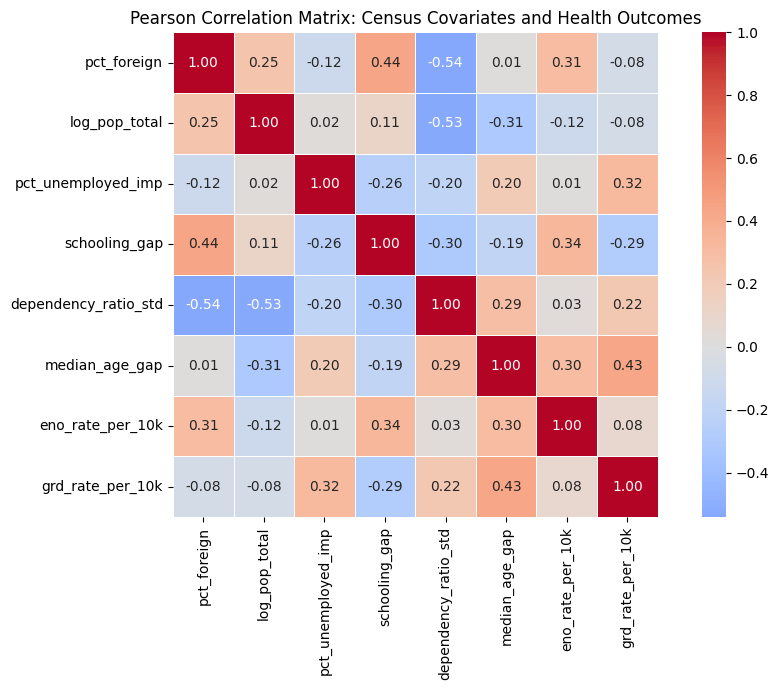

In [142]:
# ===============================
# PART 1.1 — CORRELATION MATRIX AJUSTADA
# ===============================

corr_cols = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed_imp",
    "schooling_gap",
    "dependency_ratio_std",
    "median_age_gap",
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]
corr_data = df_clean[corr_cols].replace([np.inf, -np.inf], np.nan)

print("Datos no nulos por columna:")
display(corr_data.notna().sum())

corr_matrix = corr_data.corr(method="pearson")

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix: Census Covariates and Health Outcomes")
plt.tight_layout()
plt.show()

La matriz de correlación muestra relaciones importantes entre las características demográficas de las comunas y los resultados de salud. Los valores representan asociaciones a nivel comunal, por lo que no deben interpretarse como relaciones individuales.

Las correlaciones más fuertes sugieren que existe un eje demográfico asociado a migración, estructura etaria, educación y tamaño poblacional. En los resultados preliminares, `pct_foreign` se relaciona negativamente con `dependency_ratio_std`, lo que indica que las comunas con mayor proporción de población extranjera tienden a presentar menores razones de dependencia. Este signo es razonable, ya que la población migrante suele concentrarse en edades laborales.

Además, `log_pop_total` también presenta una relación negativa con `dependency_ratio_std`, lo que sugiere que las comunas más grandes tienden a tener una menor proporción relativa de población dependiente. Esto puede reflejar diferencias entre comunas urbanas densas y comunas más pequeñas o periféricas.

Respecto a los resultados de salud, `eno_rate_per_10k` muestra una asociación positiva con `schooling_gap` y con `pct_foreign`. Esto sugiere que las comunas con mayores diferencias educacionales entre población chilena y extranjera, y con mayor proporción de población extranjera, tienden a presentar mayores tasas de notificación ENO. Sin embargo, esta asociación es ecológica y no implica que las personas extranjeras tengan mayor riesgo individual de enfermedad.

In [ ]:
# ===============================
# TOP CORRELATIONS
# ===============================

corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["var1", "var2", "correlation"]

# Quitar diagonal
corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]

# Evitar duplicados A-B y B-A
corr_pairs["pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["var1"], row["var2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("pair")
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

top_corr = corr_pairs.sort_values("abs_correlation", ascending=False).head(10)

display(top_corr)

,var1,var2,correlation,pair,abs_correlation
4,pct_foreign,dependency_ratio_std,-0.541612,"(dependency_ratio_std, pct_foreign)",0.541612
11,log_pop_total,dependency_ratio_std,-0.529745,"(dependency_ratio_std, log_pop_total)",0.529745
3,pct_foreign,schooling_gap,0.437377,"(pct_foreign, schooling_gap)",0.437377
26,schooling_gap,eno_rate_per_10k,0.339898,"(eno_rate_per_10k, schooling_gap)",0.339898
20,pct_unemployed_imp,grd_rate_per_10k,0.315192,"(grd_rate_per_10k, pct_unemployed_imp)",0.315192
5,pct_foreign,eno_rate_per_10k,0.306100,"(eno_rate_per_10k, pct_foreign)",0.306100
25,schooling_gap,dependency_ratio_std,-0.300895,"(dependency_ratio_std, schooling_gap)",0.300895
27,schooling_gap,grd_rate_per_10k,-0.287020,"(grd_rate_per_10k, schooling_gap)",0.287020
17,pct_unemployed_imp,schooling_gap,-0.257332,"(pct_unemployed_imp, schooling_gap)",0.257332
1,pct_foreign,log_pop_total,0.248533,"(log_pop_total, pct_foreign)",0.248533


In [ ]:
# ===============================
# TOP CORRELATIONS AJUSTADAS
# ===============================

corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["var1", "var2", "correlation"]

corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]

corr_pairs["pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["var1"], row["var2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("pair")
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

top_corr = corr_pairs.sort_values("abs_correlation", ascending=False).head(10)

display(top_corr)

,var1,var2,correlation,pair,abs_correlation
4,pct_foreign,dependency_ratio_std,-0.541612,"(dependency_ratio_std, pct_foreign)",0.541612
11,log_pop_total,dependency_ratio_std,-0.529745,"(dependency_ratio_std, log_pop_total)",0.529745
3,pct_foreign,schooling_gap,0.437377,"(pct_foreign, schooling_gap)",0.437377
26,schooling_gap,eno_rate_per_10k,0.339898,"(eno_rate_per_10k, schooling_gap)",0.339898
20,pct_unemployed_imp,grd_rate_per_10k,0.315192,"(grd_rate_per_10k, pct_unemployed_imp)",0.315192
5,pct_foreign,eno_rate_per_10k,0.306100,"(eno_rate_per_10k, pct_foreign)",0.306100
25,schooling_gap,dependency_ratio_std,-0.300895,"(dependency_ratio_std, schooling_gap)",0.300895
27,schooling_gap,grd_rate_per_10k,-0.287020,"(grd_rate_per_10k, schooling_gap)",0.287020
17,pct_unemployed_imp,schooling_gap,-0.257332,"(pct_unemployed_imp, schooling_gap)",0.257332
1,pct_foreign,log_pop_total,0.248533,"(log_pop_total, pct_foreign)",0.248533


## 1.2 Bivariate scatter plots





A continuación se presentan gráficos de dispersión entre cada covariable censal y los resultados de salud. Cada panel incluye una línea de ajuste simple para visualizar la dirección general de la relación.

En cada gráfico se etiquetan las cinco comunas con mayores residuos absolutos, ya que estas comunas se comportan como outliers visuales respecto de la tendencia bivariada.



pct_foreign vs eno_rate_per_10k: 51 comunas
pct_unemployed_imp vs eno_rate_per_10k: 51 comunas
schooling_gap vs eno_rate_per_10k: 48 comunas
dependency_ratio_std vs eno_rate_per_10k: 51 comunas
log_pop_total vs eno_rate_per_10k: 51 comunas
employment_rate_imp vs eno_rate_per_10k: 51 comunas


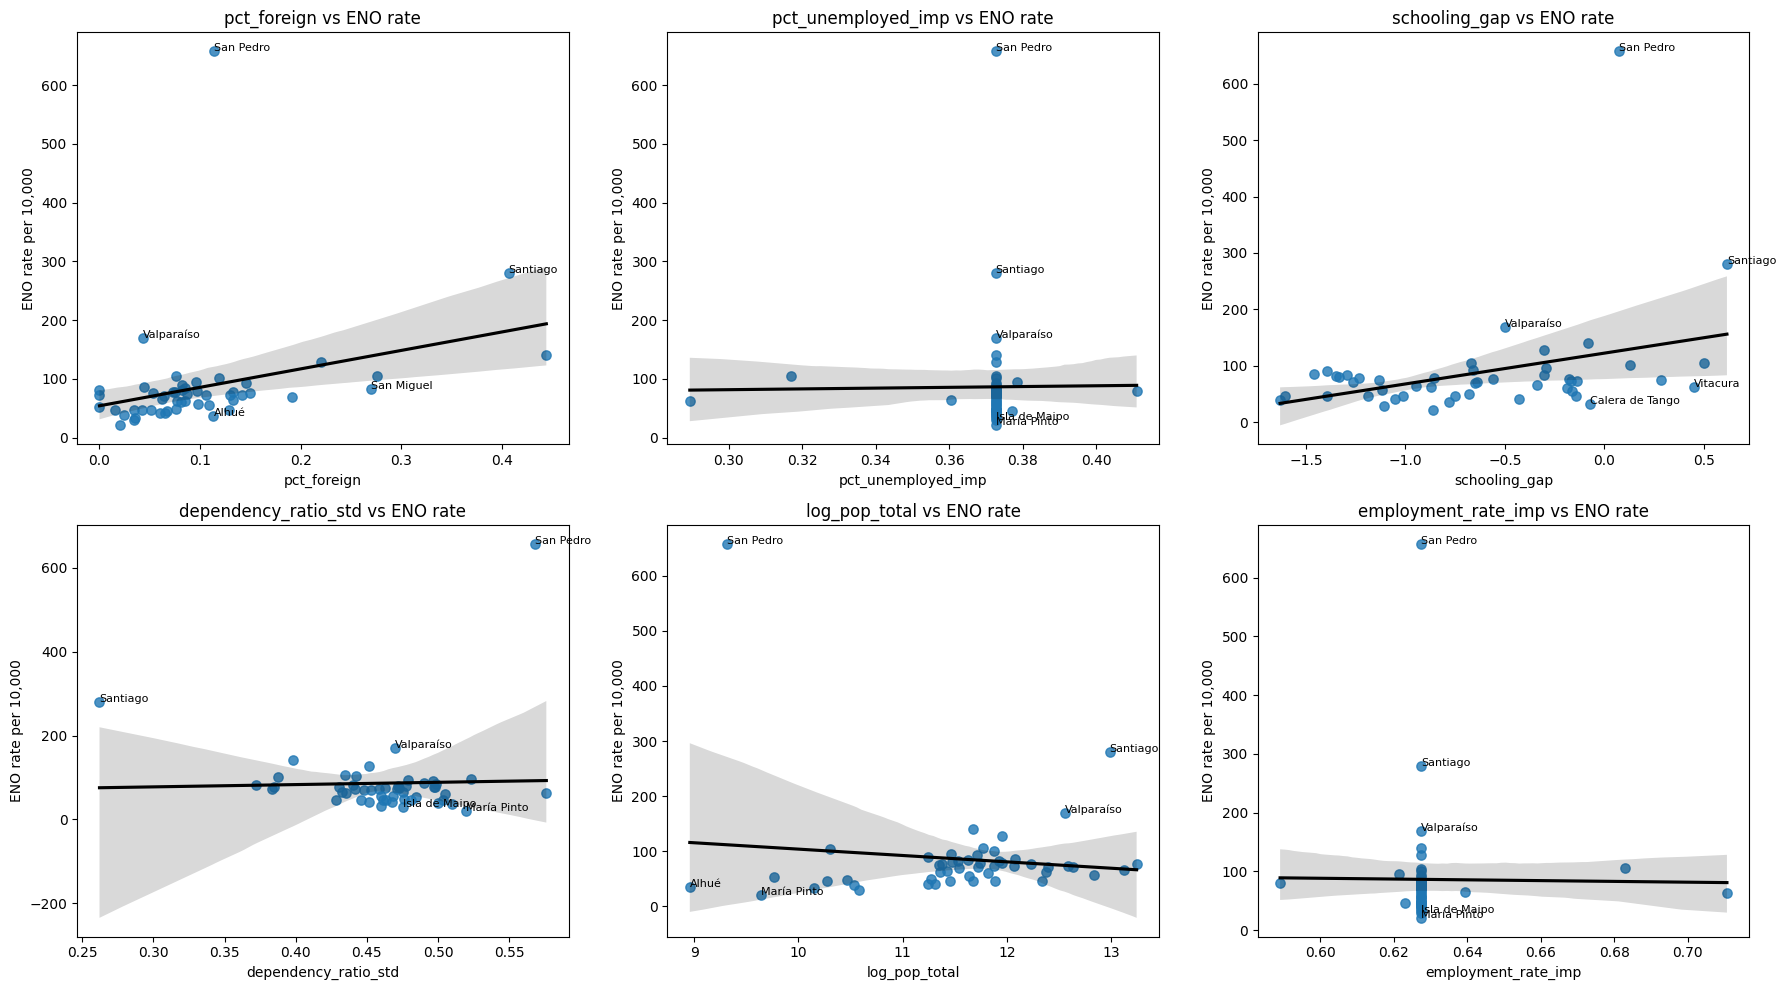

In [ ]:
# ===============================
# PART 1.2 — SCATTER PLOTS ENO
# ===============================

import statsmodels.api as sm

scatter_covariates = [
    "pct_foreign",
    "pct_unemployed_imp",
    "schooling_gap",
    "dependency_ratio_std",
    "log_pop_total",
    "employment_rate_imp"
]

outcome = "eno_rate_per_10k"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var in zip(axes, scatter_covariates):

    # Dropna solo para este gráfico
    tmp = df_clean[
        ["nombre_comuna_final", var, outcome]
    ].replace([np.inf, -np.inf], np.nan).dropna().copy()

    print(f"{var} vs {outcome}: {tmp.shape[0]} comunas")

    sns.regplot(
        data=tmp,
        x=var,
        y=outcome,
        ax=ax,
        scatter_kws={"s": 45, "alpha": 0.8},
        line_kws={"color": "black"}
    )

    # Etiquetar 5 residuos más extremos
    if tmp.shape[0] >= 3:
        X_tmp = sm.add_constant(tmp[var])
        y_tmp = tmp[outcome]
        ols_tmp = sm.OLS(y_tmp, X_tmp).fit()
        tmp["abs_resid"] = np.abs(ols_tmp.resid)

        label_df = tmp.sort_values("abs_resid", ascending=False).head(5)

        for _, r in label_df.iterrows():
            ax.text(
                r[var],
                r[outcome],
                str(r["nombre_comuna_final"]),
                fontsize=8
            )

    ax.set_title(f"{var} vs ENO rate")
    ax.set_xlabel(var)
    ax.set_ylabel("ENO rate per 10,000")

plt.tight_layout()
plt.show()

pct_foreign vs grd_rate_per_10k: 51 comunas
pct_unemployed_imp vs grd_rate_per_10k: 51 comunas
schooling_gap vs grd_rate_per_10k: 48 comunas
dependency_ratio_std vs grd_rate_per_10k: 51 comunas
log_pop_total vs grd_rate_per_10k: 51 comunas
employment_rate_imp vs grd_rate_per_10k: 51 comunas


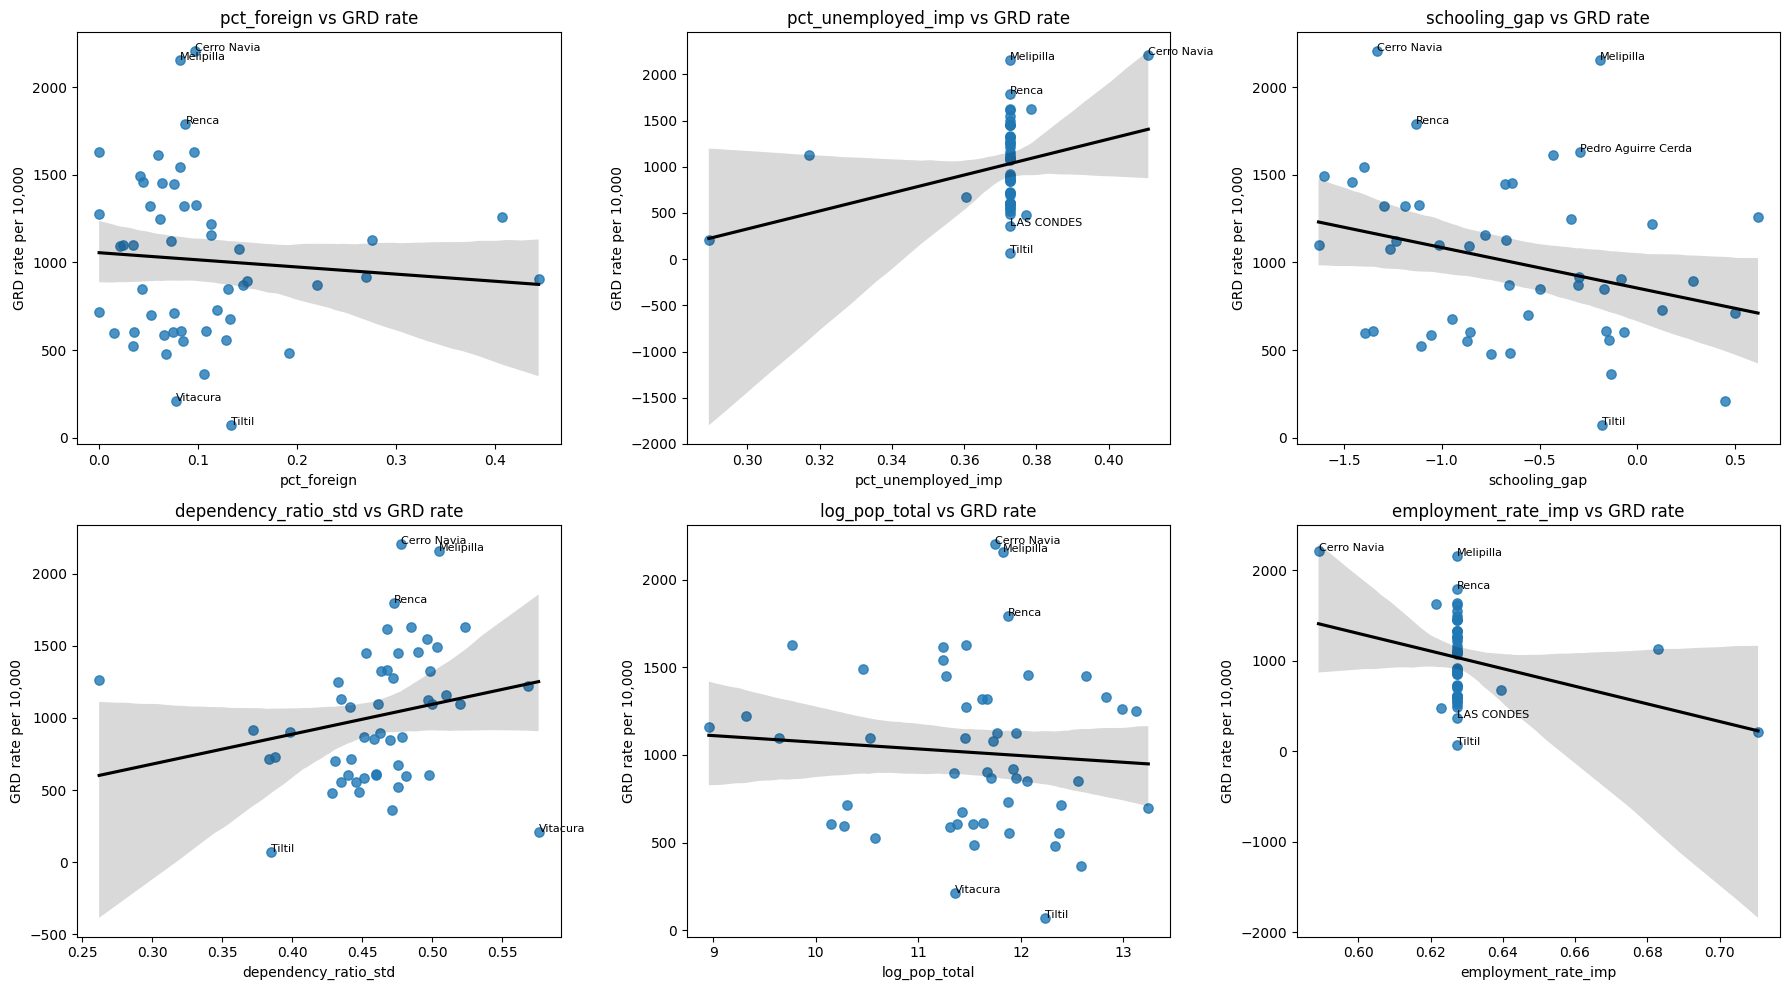

In [ ]:
# ===============================
# PART 1.2 — SCATTER PLOTS GRD
# ===============================

outcome = "grd_rate_per_10k"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var in zip(axes, scatter_covariates):

    tmp = df_clean[
        ["nombre_comuna_final", var, outcome]
    ].replace([np.inf, -np.inf], np.nan).dropna().copy()

    print(f"{var} vs {outcome}: {tmp.shape[0]} comunas")

    sns.regplot(
        data=tmp,
        x=var,
        y=outcome,
        ax=ax,
        scatter_kws={"s": 45, "alpha": 0.8},
        line_kws={"color": "black"}
    )

    if tmp.shape[0] >= 3:
        X_tmp = sm.add_constant(tmp[var])
        y_tmp = tmp[outcome]
        ols_tmp = sm.OLS(y_tmp, X_tmp).fit()
        tmp["abs_resid"] = np.abs(ols_tmp.resid)

        label_df = tmp.sort_values("abs_resid", ascending=False).head(5)

        for _, r in label_df.iterrows():
            ax.text(
                r[var],
                r[outcome],
                str(r["nombre_comuna_final"]),
                fontsize=8
            )

    ax.set_title(f"{var} vs GRD rate")
    ax.set_xlabel(var)
    ax.set_ylabel("GRD rate per 10,000")

plt.tight_layout()
plt.show()

Los gráficos de dispersión muestran que las tasas ENO están influenciadas por algunas comunas con valores especialmente altos. En particular, las comunas con menor población pueden mostrar tasas elevadas cuando tienen un número moderado de notificaciones, debido al efecto del denominador pequeño.

En el caso de GRD, la relación con las variables migratorias parece ser más débil. En cambio, se observan patrones más visibles con variables asociadas a estructura demográfica y condiciones socioeconómicas, como la razón de dependencia o el desempleo. Esto sugiere que las tasas de egresos hospitalarios podrían estar más relacionadas con necesidades de salud, estructura etaria y patrones de uso del sistema hospitalario que con la composición migratoria por sí sola.

## 1.3 Outlier and leverage discussion

En esta sección se identifican comunas con tasas ENO y GRD inusualmente altas o bajas respecto de la distribución general. Estas comunas pueden influir en las correlaciones y en las líneas de ajuste de los gráficos bivariados.

Los outliers no deben interpretarse automáticamente como errores. Pueden reflejar diferencias reales en carga de enfermedad, acceso a servicios de salud, intensidad de notificación, estructura poblacional o dinámicas locales de atención hospitalaria.

In [ ]:
# ===============================
# PART 1.3 — OUTLIERS
# ===============================

from scipy import stats

outlier_df = df_clean[
    [
        "codigo_comuna",
        "nombre_comuna_final",
        "eno_rate_per_10k",
        "grd_rate_per_10k",
        "pct_foreign",
        "pct_unemployed_imp",
        "schooling_gap",
        "dependency_ratio_std",
        "log_pop_total"
    ]
].replace([np.inf, -np.inf], np.nan).dropna().copy()

outlier_df["eno_z"] = stats.zscore(outlier_df["eno_rate_per_10k"])
outlier_df["grd_z"] = stats.zscore(outlier_df["grd_rate_per_10k"])

print("Top ENO outliers:")
display(
    outlier_df
    .reindex(outlier_df["eno_z"].abs().sort_values(ascending=False).index)
    .head(10)
)

print("Top GRD outliers:")
display(
    outlier_df
    .reindex(outlier_df["grd_z"].abs().sort_values(ascending=False).index)
    .head(10)
)

Top ENO outliers:


,codigo_comuna,nombre_comuna_final,eno_rate_per_10k,grd_rate_per_10k,pct_foreign,pct_unemployed_imp,schooling_gap,dependency_ratio_std,log_pop_total,eno_z,grd_z
45,13505,San Pedro,658.084264,1219.841556,0.113432,0.372612,0.075178,0.568262,9.315421,6.151318,0.467663
2,13101,Santiago,279.890212,1261.619027,0.406436,0.372612,0.616190,0.262107,12.983986,2.074663,0.557388
0,5101,Valparaíso,169.194702,848.605662,0.043237,0.372612,-0.500000,0.469800,12.560027,0.881446,-0.329634
44,13504,María Pinto,20.844190,1096.274101,0.020779,0.372612,-0.860000,0.520000,9.639001,-0.717664,0.202279
48,13603,Isla de Maipo,29.281458,524.265417,0.033916,0.372612,-1.108601,0.475634,10.578318,-0.626716,-1.026214
39,13403,Calera de Tango,32.952807,603.742497,0.035228,0.372612,-0.070000,0.459700,10.146081,-0.587142,-0.855523
8,13108,Independencia,140.410285,904.115680,0.443874,0.372612,-0.082220,0.398355,11.669442,0.571171,-0.210416
42,13502,Alhué,36.045314,1158.599382,0.113157,0.372612,-0.780000,0.510000,8.957768,-0.553807,0.336134
47,13602,El Monte,38.936448,1097.154439,0.024402,0.372612,-1.630000,0.500000,10.532016,-0.522643,0.204170
46,13601,Talagante,41.083882,1614.832066,0.059650,0.372612,-0.430000,0.467600,11.244117,-0.499495,1.315978


Top GRD outliers:


,codigo_comuna,nombre_comuna_final,eno_rate_per_10k,grd_rate_per_10k,pct_foreign,pct_unemployed_imp,schooling_gap,dependency_ratio_std,log_pop_total,eno_z,grd_z
4,13103,Cerro Navia,79.435548,2207.547170,0.096948,0.410991,-1.332292,0.477499,11.745148,-0.086092,2.588942
41,13501,Melipilla,60.443792,2156.904456,0.081196,0.372612,-0.190000,0.504800,11.822797,-0.290809,2.480178
24,13125,Tiltil,77.422869,69.787573,0.132815,0.372612,-0.180000,0.385000,12.233805,-0.107787,-2.002289
31,13132,Vitacura,62.922505,209.351828,0.077144,0.289352,0.449561,0.576132,11.356295,-0.264091,-1.702549
27,13128,Renca,74.083358,1792.761555,0.087194,0.372612,-1.132814,0.472578,11.874940,-0.143785,1.698114
13,13114,LAS CONDES,72.521939,364.010262,0.106132,0.372612,-0.136625,0.471198,12.587037,-0.160616,-1.370392
20,13121,Pedro Aguirre Cerda,95.397840,1628.787085,0.095377,0.378527,-0.291600,0.523315,11.465729,0.085970,1.345949
46,13601,Talagante,41.083882,1614.832066,0.059650,0.372612,-0.430000,0.467600,11.244117,-0.499495,1.315978
30,13131,San Ramón,90.392358,1545.090919,0.081761,0.372612,-1.395956,0.496692,11.238515,0.032014,1.166196
23,13124,Pudahuel,46.132912,478.886840,0.067351,0.377058,-0.749267,0.428643,12.336311,-0.445070,-1.123673


San Pedro aparece como el outlier más claro en ENO, con la mayor tasa de notificaciones por cada 10.000 habitantes dentro de la tabla analizada. Esto no necesariamente significa que San Pedro tenga el mayor riesgo individual de enfermedad. Debido a que es una comuna con menor población, un número moderado de notificaciones puede producir una tasa muy alta. Por lo tanto, el efecto del denominador pequeño debe considerarse al interpretar las tasas comunales.

Santiago también aparece como un outlier relevante en ENO. Su tasa de notificaciones es alta en comparación con la mayoría de las comunas, y además concentra un número absoluto elevado de notificaciones. Una explicación plausible es que Santiago reúne una población grande, diversa y altamente móvil, además de una mayor disponibilidad de servicios de diagnóstico y capacidad de notificación. Por ello, su tasa puede reflejar tanto carga epidemiológica como mayor intensidad de vigilancia.

En el caso de GRD, comunas como Cerro Navia y Melipilla aparecen con tasas elevadas de egresos hospitalarios. Estos casos pueden estar asociados a mayores necesidades de salud, condiciones socioeconómicas, estructura etaria, acceso a hospitales o patrones de derivación. Dado que GRD mide egresos hospitalarios y no incidencia individual de enfermedad, estos outliers deben interpretarse como patrones territoriales de uso hospitalario, no como evidencia directa de mayor riesgo individual.

## Resumen de la Parte 1

En conjunto, el análisis exploratorio muestra que la composición demográfica de las comunas se asocia con ciertos resultados de salud, aunque la intensidad y dirección de estas relaciones varía según el resultado analizado.

Las tasas ENO parecen mostrar una relación más clara con variables como la proporción de población extranjera y la brecha educacional. En cambio, las tasas GRD presentan una relación menos directa con la migración y parecen estar más vinculadas a factores demográficos y socioeconómicos más amplios.

La presencia de outliers importantes indica que los modelos de regresión deben interpretarse con cautela. Además, dado que el análisis se realiza a nivel comunal, los resultados corresponden a asociaciones ecológicas y no permiten hacer afirmaciones causales a nivel individual.

# Part 2: Count-Data Regression

En esta sección se modelan los conteos comunales de ENO y GRD utilizando modelos de conteo. Como las comunas tienen tamaños poblacionales muy distintos, no se deben comparar los conteos brutos directamente. Por esta razón, se utiliza `log(pop_total)` como offset poblacional, lo que permite modelar tasas en lugar de conteos absolutos.

Primero se ajusta un modelo Poisson para las notificaciones ENO. Luego se evalúa la sobredispersión mediante el estadístico Pearson chi-square dividido por los grados de libertad residuales. Si este valor es sustancialmente mayor que 1, se utiliza un modelo Binomial Negativo, ya que permite que la varianza sea mayor que la media.

Las covariables incluidas son: proporción de población extranjera, brecha educacional, desempleo imputado y razón de dependencia. Dado que las variables porcentuales están expresadas como proporciones, se reescalan para que los coeficientes representen cambios por cada 10 puntos porcentuales.

In [ ]:
# ===============================
# PART 2.0 — PREPARAR VARIABLES PARA MODELOS
# ===============================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# Copia de trabajo
model_base = df_clean.copy()

# Reescalar variables para interpretar por 10 puntos porcentuales
model_base["pct_foreign_10pp"] = model_base["pct_foreign"] / 0.10
model_base["pct_unemployed_10pp"] = model_base["pct_unemployed_imp"] / 0.10
model_base["dependency_ratio_10pp"] = model_base["dependency_ratio_std"] / 0.10

# Covariables del modelo
covariates_count = [
    "pct_foreign_10pp",
    "schooling_gap",
    "pct_unemployed_10pp",
    "dependency_ratio_10pp"
]

# Dataset para modelos de conteo
count_df = model_base[
    [
        "codigo_comuna",
        "nombre_comuna_final",
        "pop_total",
        "eno_total",
        "grd_total"
    ] + covariates_count
].copy()

# Convertir a numérico
for col in ["pop_total", "eno_total", "grd_total"] + covariates_count:
    count_df[col] = pd.to_numeric(count_df[col], errors="coerce")

# Limpiar NaN e infinitos
count_df = count_df.replace([np.inf, -np.inf], np.nan)

# Eliminar filas incompletas para los modelos
count_df = count_df.dropna(subset=["pop_total", "eno_total", "grd_total"] + covariates_count)

# Asegurar población válida
count_df = count_df[count_df["pop_total"] > 0]

print("Filas usadas en modelos de conteo:", count_df.shape[0])
display(count_df.head())
display(count_df.describe().T)

Filas usadas en modelos de conteo: 48


,codigo_comuna,nombre_comuna_final,pop_total,eno_total,grd_total,pct_foreign_10pp,schooling_gap,pct_unemployed_10pp,dependency_ratio_10pp
0,5101,Valparaíso,284938.0,4821,24180,0.432375,-0.500000,3.726116,4.698000
1,5102,Casablanca,29876.0,312,2134,0.759472,0.500000,3.726116,4.421000
2,13101,Santiago,435385.0,12186,54929,4.064357,0.616190,3.726116,2.621068
3,13102,Cerrillos,85041.0,642,7623,1.497160,0.286000,3.726116,4.630000
4,13103,Cerro Navia,126140.0,1002,27846,0.969478,-1.332292,4.109907,4.774990


,count,mean,std,min,25%,50%,75%,max
codigo_comuna,48.0,12908.520833,1655.082848,5101.000000,13111.750000,13125.500000,13402.250000,13605.000000
pop_total,48.0,146958.041667,122244.264769,7768.000000,80639.250000,116956.000000,159766.000000,564477.000000
eno_total,48.0,1320.958333,1885.309783,28.000000,513.750000,861.000000,1463.000000,12186.000000
grd_total,48.0,14653.270833,14467.420007,900.000000,5163.000000,10783.000000,15477.000000,62614.000000
pct_foreign_10pp,48.0,1.085593,0.874804,0.152099,0.613163,0.837462,1.285988,4.438744
schooling_gap,48.0,-0.640406,0.583092,-1.630000,-1.122129,-0.665458,-0.177500,0.616190
pct_unemployed_10pp,48.0,3.704815,0.156312,2.893520,3.726116,3.726116,3.726116,4.109907
dependency_ratio_10pp,48.0,4.625838,0.497693,2.621068,4.419070,4.655606,4.916729,5.761318


## Parte 2.0: Preparación de variables

Antes de ajustar los modelos, se construyó una base específica para regresiones de conteo. Las variables porcentuales fueron reescaladas para facilitar la interpretación: los coeficientes asociados a `pct_foreign_10pp`, `pct_unemployed_10pp` y `dependency_ratio_10pp` representan cambios por cada 10 puntos porcentuales.

Las filas con valores faltantes o infinitos en las variables necesarias fueron eliminadas para evitar errores en el ajuste de los modelos.

## Revisión de multicolinealidad

In [143]:
display(count_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
codigo_comuna,48.0,12908.520833,1655.082848,5101.000000,13111.750000,13125.500000,13402.250000,13605.000000
pop_total,48.0,146958.041667,122244.264769,7768.000000,80639.250000,116956.000000,159766.000000,564477.000000
eno_total,48.0,1320.958333,1885.309783,28.000000,513.750000,861.000000,1463.000000,12186.000000
grd_total,48.0,14653.270833,14467.420007,900.000000,5163.000000,10783.000000,15477.000000,62614.000000
pct_foreign_10pp,48.0,1.085593,0.874804,0.152099,0.613163,0.837462,1.285988,4.438744
schooling_gap,48.0,-0.640406,0.583092,-1.630000,-1.122129,-0.665458,-0.177500,0.616190
pct_unemployed_10pp,48.0,3.704815,0.156312,2.893520,3.726116,3.726116,3.726116,4.109907
dependency_ratio_10pp,48.0,4.625838,0.497693,2.621068,4.419070,4.655606,4.916729,5.761318


In [144]:
# ===============================
# PART 2.0.1 — REVISIÓN DE MULTICOLINEALIDAD: VIF
# ===============================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = count_df[covariates_count].copy()
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

display(vif_table)

,variable,VIF
0,const,1148.290690
1,pct_foreign_10pp,1.872961
2,schooling_gap,1.332013
3,pct_unemployed_10pp,1.236563
4,dependency_ratio_10pp,1.830572


La revisión de multicolinealidad mediante VIF no muestra problemas importantes entre las covariables del modelo. Aunque el VIF de la constante es alto, este valor no se interpreta sustantivamente. Las variables explicativas principales presentan VIF menores a 2, lo que indica baja colinealidad entre ellas.

Por lo tanto, las estimaciones del modelo no parecen estar fuertemente afectadas por redundancia lineal entre `pct_foreign_10pp`, `schooling_gap`, `pct_unemployed_10pp` y `dependency_ratio_10pp`. Esto permite interpretar los coeficientes con mayor confianza en términos de dirección y magnitud, aunque los resultados siguen estando limitados por el tamaño muestral reducido y el carácter ecológico del análisis.

## Parte 2.1: Modelo Poisson para ENO

Se ajustó un modelo Poisson usando `eno_total` como variable dependiente y `log(pop_total)` como offset. Esto permite modelar la tasa esperada de notificaciones ENO por comuna, controlando por el tamaño de la población.

La tabla de resultados se presenta tanto en coeficientes log-lineales como en razones de tasas de incidencia (IRR). Un IRR mayor que 1 indica una asociación positiva con la tasa esperada de notificaciones, mientras que un IRR menor que 1 indica una asociación negativa, manteniendo constantes las demás covariables.

In [145]:
# ===============================
# PART 2.1 — POISSON REGRESSION PARA ENO
# ===============================

y_eno = count_df["eno_total"]

X_eno = count_df[covariates_count]
X_eno = sm.add_constant(X_eno)

offset_eno = np.log(count_df["pop_total"])

poisson_eno = sm.GLM(
    y_eno,
    X_eno,
    family=sm.families.Poisson(),
    offset=offset_eno
).fit()

print(poisson_eno.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   48
Model:                            GLM   Df Residuals:                       43
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4287.3
Date:                Mon, 04 May 2026   Deviance:                       8169.3
Time:                        01:35:10   Pearson chi2:                 1.17e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -5.52

In [ ]:
# ===============================
# IRR TABLE — POISSON ENO
# ===============================

def make_irr_table(model):
    conf = model.conf_int()

    irr_table = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "z_value": model.tvalues,
        "p_value": model.pvalues,
        "IRR": np.exp(model.params),
        "IRR_low_95": np.exp(conf[0]),
        "IRR_high_95": np.exp(conf[1])
    })

    return irr_table

poisson_eno_irr = make_irr_table(poisson_eno)

display(poisson_eno_irr)

print("Modelo Poisson ENO — indicadores de ajuste")
print("Deviance:", poisson_eno.deviance)
print("Pearson chi-square:", poisson_eno.pearson_chi2)
print("AIC:", poisson_eno.aic)

,coef,std_err,z_value,p_value,IRR,IRR_low_95,IRR_high_95
const,-5.520352,0.156840,-35.197426,2.189349e-271,0.004004,0.002945,0.005446
pct_foreign_10pp,0.211432,0.005642,37.472728,2.562084e-307,1.235446,1.221859,1.249184
schooling_gap,0.243952,0.010481,23.274577,8.022539e-120,1.276284,1.250332,1.302774
pct_unemployed_10pp,0.286630,0.035497,8.074730,6.762607e-16,1.331931,1.242415,1.427898
dependency_ratio_10pp,-0.102214,0.010810,-9.455412,3.217530e-21,0.902837,0.883909,0.922169


Modelo Poisson ENO — indicadores de ajuste
Deviance: 8169.314786990829
Pearson chi-square: 11697.62122335566
AIC: 8584.515596969877


### Resultados del modelo Poisson para ENO

En el modelo Poisson para ENO, todas las covariables aparecen como estadísticamente significativas al 5%. Según los IRR, `pct_foreign_10pp`, `schooling_gap` y `pct_unemployed_10pp` se asocian positivamente con la tasa esperada de notificaciones ENO, mientras que `dependency_ratio_10pp` aparece con una asociación negativa.

Sin embargo, estos resultados deben interpretarse con cautela. El modelo Poisson puede producir errores estándar demasiado pequeños cuando existe sobredispersión. Por lo tanto, antes de tomar estas asociaciones como resultado principal, se revisa si el supuesto de igualdad entre media y varianza es razonable.

En los modelos de conteo se utilizan 48 comunas, aunque la tabla analítica contiene 51. La diferencia se debe a que algunas comunas tienen valores faltantes en `schooling_gap`, variable necesaria para el modelo. Estas filas se eliminan solo para la regresión, evitando imputar valores educacionales que podrían alterar la interpretación.

## Parte 2.2: Revisión de sobredispersión

El modelo Poisson asume que la media y la varianza del conteo son iguales. Para evaluar este supuesto, se calculó el estadístico de dispersión como Pearson chi-square dividido por los grados de libertad residuales.



In [ ]:
# ===============================
# PART 2.2 — OVERDISPERSION CHECK
# ===============================

dispersion_eno = poisson_eno.pearson_chi2 / poisson_eno.df_resid

print("Estadístico de sobredispersión ENO:", dispersion_eno)

if dispersion_eno > 1.5:
    print("Hay evidencia de sobredispersión. Conviene usar Binomial Negativo.")
else:
    print("No hay evidencia fuerte de sobredispersión. Poisson podría ser aceptable.")

Estadístico de sobredispersión ENO: 272.0377028687363
Hay evidencia de sobredispersión. Conviene usar Binomial Negativo.


## Revisión de sobredispersión en ENO

El estadístico de sobredispersión para ENO es 272.04, calculado como Pearson chi-square dividido por los grados de libertad residuales. Este valor está muy por encima de 1, lo que indica una sobredispersión severa.

Esto significa que la varianza observada de los conteos ENO es mucho mayor que la esperada bajo el modelo Poisson. En consecuencia, el modelo Poisson subestima los errores estándar y puede hacer que las covariables aparezcan artificialmente como significativas.

Por esta razón, el modelo Poisson no se considera adecuado como resultado principal para ENO. Se ajusta un modelo Binomial Negativo, que permite que la varianza sea mayor que la media.

## Parte 2.3: Modelo Binomial Negativo para ENO

Dado que los conteos comunales suelen presentar sobredispersión, se ajustó un modelo Binomial Negativo con las mismas covariables y el mismo offset poblacional. Este modelo es más flexible que Poisson porque permite que la varianza sea mayor que la media.

La comparación entre Poisson y Binomial Negativo permite observar si cambian los coeficientes, los errores estándar o los valores-p. Si una variable es significativa en Poisson pero deja de serlo en Binomial Negativo, eso sugiere que la evidencia era sensible al supuesto de varianza del modelo Poisson.

El modelo principal para ENO se selecciona según el estadístico de sobredispersión. Si existe sobredispersión, se reporta el modelo Binomial Negativo como resultado principal.

In [107]:
# ===============================
# PART 2.3 — NEGATIVE BINOMIAL PARA ENO
# ===============================

nb_eno = sm.GLM(
    y_eno,
    X_eno,
    family=sm.families.NegativeBinomial(),
    offset=offset_eno
).fit()

print(nb_eno.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   48
Model:                            GLM   Df Residuals:                       43
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -370.36
Date:                Sun, 03 May 2026   Deviance:                       10.648
Time:                        23:20:39   Pearson chi2:                     13.7
No. Iterations:                    15   Pseudo R-squ. (CS):             0.1821
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -11.32

In [108]:
# ===============================
# IRR TABLE — NEGATIVE BINOMIAL ENO
# ===============================

nb_eno_irr = make_irr_table(nb_eno)

display(nb_eno_irr)

print("Modelo Binomial Negativo ENO — indicadores de ajuste")
print("Deviance:", nb_eno.deviance)
print("Pearson chi-square:", nb_eno.pearson_chi2)
print("AIC:", nb_eno.aic)

,coef,std_err,z_value,p_value,IRR,IRR_low_95,IRR_high_95
const,-11.323172,4.895334,-2.313054,0.020720,0.000012,8.231769e-10,0.177552
pct_foreign_10pp,0.434533,0.228363,1.902813,0.057065,1.544241,9.870335e-01,2.416009
schooling_gap,0.390746,0.289056,1.351798,0.176440,1.478082,8.387908e-01,2.604616
pct_unemployed_10pp,1.004834,1.038422,0.967655,0.333217,2.731454,3.568514e-01,20.907408
dependency_ratio_10pp,0.548757,0.396979,1.382333,0.166870,1.731099,7.950841e-01,3.769041


Modelo Binomial Negativo ENO — indicadores de ajuste
Deviance: 10.647643752377665
Pearson chi-square: 13.687374485189524
AIC: 750.7164015041049


### Interpretación del modelo principal ENO

El modelo principal para ENO es Binomial Negativo. La variable con asociación más relevante es `pct_foreign_10pp`, con un IRR de 1.54. Esto sugiere que, manteniendo constantes las demás covariables, un aumento de 10 puntos porcentuales en la proporción de población extranjera se asocia con una tasa esperada de notificaciones ENO aproximadamente 54% mayor.

Sin embargo, esta asociación debe interpretarse con cautela. El valor-p es 0.057, por lo que no alcanza significancia estadística al 5%, aunque sí sugiere una relación marginal. Además, el intervalo de confianza incluye 1, lo que indica incertidumbre sobre la magnitud real de la asociación.



In [109]:
# ===============================
# COMPARACIÓN POISSON VS NEGATIVE BINOMIAL
# ===============================

comparison_eno = pd.DataFrame({
    "poisson_coef": poisson_eno.params,
    "poisson_p": poisson_eno.pvalues,
    "nb_coef": nb_eno.params,
    "nb_p": nb_eno.pvalues,
    "poisson_IRR": np.exp(poisson_eno.params),
    "nb_IRR": np.exp(nb_eno.params)
})

comparison_eno["changes_significance_5pct"] = (
    (comparison_eno["poisson_p"] < 0.05) !=
    (comparison_eno["nb_p"] < 0.05)
)

display(comparison_eno)

,poisson_coef,poisson_p,nb_coef,nb_p,poisson_IRR,nb_IRR,changes_significance_5pct
const,-5.520352,2.189349e-271,-11.323172,0.020720,0.004004,0.000012,False
pct_foreign_10pp,0.211432,2.562084e-307,0.434533,0.057065,1.235446,1.544241,True
schooling_gap,0.243952,8.022539e-120,0.390746,0.176440,1.276284,1.478082,True
pct_unemployed_10pp,0.286630,6.762607e-16,1.004834,0.333217,1.331931,2.731454,True
dependency_ratio_10pp,-0.102214,3.217530e-21,0.548757,0.166870,0.902837,1.731099,True


### Comparación Poisson versus Binomial Negativo para ENO

La comparación entre Poisson y Binomial Negativo muestra que las conclusiones cambian de manera importante. En el modelo Poisson, todas las covariables aparecen como estadísticamente significativas. Sin embargo, en el modelo Binomial Negativo ninguna covariable mantiene significancia estadística al 5%.

Esto ocurre porque el modelo Poisson no captura la sobredispersión presente en los conteos ENO. Al permitir una varianza mayor que la media, el modelo Binomial Negativo entrega errores estándar más realistas y una inferencia más prudente.

Por lo tanto, las conclusiones sustantivas se basan en el modelo Binomial Negativo y no en el modelo Poisson.

In [110]:
# ===============================
# MODELO PRINCIPAL ENO
# ===============================

if dispersion_eno > 1.5:
    primary_eno_model = nb_eno
    primary_eno_name = "Negative Binomial"
    primary_eno_irr = nb_eno_irr
else:
    primary_eno_model = poisson_eno
    primary_eno_name = "Poisson"
    primary_eno_irr = poisson_eno_irr

print("Modelo principal seleccionado para ENO:", primary_eno_name)
display(primary_eno_irr)

Modelo principal seleccionado para ENO: Negative Binomial


,coef,std_err,z_value,p_value,IRR,IRR_low_95,IRR_high_95
const,-11.323172,4.895334,-2.313054,0.020720,0.000012,8.231769e-10,0.177552
pct_foreign_10pp,0.434533,0.228363,1.902813,0.057065,1.544241,9.870335e-01,2.416009
schooling_gap,0.390746,0.289056,1.351798,0.176440,1.478082,8.387908e-01,2.604616
pct_unemployed_10pp,1.004834,1.038422,0.967655,0.333217,2.731454,3.568514e-01,20.907408
dependency_ratio_10pp,0.548757,0.396979,1.382333,0.166870,1.731099,7.950841e-01,3.769041


### Interpretación del modelo principal ENO

El modelo principal para ENO es Binomial Negativo. La variable con asociación más relevante es `pct_foreign_10pp`, con un IRR de 1.54. Esto sugiere que, manteniendo constantes las demás variables, un aumento de 10 puntos porcentuales en la proporción de población extranjera se asocia con una tasa esperada de notificaciones ENO aproximadamente 54% mayor.

Sin embargo, esta asociación debe interpretarse con cautela. El valor-p es 0.057, por lo que no alcanza significancia estadística al 5%, aunque sí sugiere una relación marginal. Además, el intervalo de confianza incluye 1, lo que indica incertidumbre sobre la magnitud real de la asociación.

Las demás variables también presentan IRR mayores que 1, pero ninguna alcanza significancia estadística al 5% en el modelo Binomial Negativo. Esto refuerza la idea de que los resultados deben interpretarse como evidencia descriptiva y no como efectos concluyentes.

## Parte 2.4: Modelo de conteo para GRD

Se ajustó un segundo modelo de conteo utilizando `grd_total` como variable dependiente y el mismo offset poblacional `log(pop_total)`. De esta forma, el modelo estima asociaciones con la tasa esperada de egresos hospitalarios GRD, y no simplemente con el número bruto de egresos.

Al igual que en ENO, se revisó la sobredispersión del modelo Poisson. Si el estadístico de dispersión fue sustancialmente mayor que 1, se seleccionó el modelo Binomial Negativo como resultado principal. La tabla IRR resume el cambio multiplicativo en la tasa esperada de egresos hospitalarios asociado a cada covariable.

In [111]:
# ===============================
# PART 2.4 — MODELO DE CONTEO PARA GRD
# ===============================

y_grd = count_df["grd_total"]

X_grd = count_df[covariates_count]
X_grd = sm.add_constant(X_grd)

offset_grd = np.log(count_df["pop_total"])

poisson_grd = sm.GLM(
    y_grd,
    X_grd,
    family=sm.families.Poisson(),
    offset=offset_grd
).fit()

print(poisson_grd.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   48
Model:                            GLM   Df Residuals:                       43
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -66862.
Date:                Sun, 03 May 2026   Deviance:                   1.3320e+05
Time:                        23:21:14   Pearson chi2:                 1.25e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -7.70

In [112]:
# ===============================
# OVERDISPERSION GRD
# ===============================

dispersion_grd = poisson_grd.pearson_chi2 / poisson_grd.df_resid

print("Estadístico de sobredispersión GRD:", dispersion_grd)

if dispersion_grd > 1.5:
    print("Hay evidencia de sobredispersión. Conviene usar Binomial Negativo.")
else:
    print("No hay evidencia fuerte de sobredispersión. Poisson podría ser aceptable.")

Estadístico de sobredispersión GRD: 2917.1844398017533
Hay evidencia de sobredispersión. Conviene usar Binomial Negativo.


### Revisión de sobredispersión en GRD

El estadístico de sobredispersión para GRD es 2917.18, un valor extremadamente superior a 1. Esto indica que la variabilidad de los egresos hospitalarios entre comunas es mucho mayor que la esperada bajo el supuesto Poisson.

Por esta razón, el modelo Poisson tampoco es adecuado para GRD. Sus errores estándar están subestimados y sus valores-p tienden a ser demasiado pequeños. En consecuencia, se utiliza el modelo Binomial Negativo como modelo principal para los egresos hospitalarios GRD.

In [113]:
# ===============================
# NEGATIVE BINOMIAL PARA GRD
# ===============================

nb_grd = sm.GLM(
    y_grd,
    X_grd,
    family=sm.families.NegativeBinomial(),
    offset=offset_grd
).fit()

print(nb_grd.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   48
Model:                            GLM   Df Residuals:                       43
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -490.85
Date:                Sun, 03 May 2026   Deviance:                       10.577
Time:                        23:21:27   Pearson chi2:                     8.84
No. Iterations:                    10   Pseudo R-squ. (CS):            0.05635
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -9.15

In [114]:
# ===============================
# MODELO PRINCIPAL GRD + IRR
# ===============================

poisson_grd_irr = make_irr_table(poisson_grd)
nb_grd_irr = make_irr_table(nb_grd)

if dispersion_grd > 1.5:
    primary_grd_model = nb_grd
    primary_grd_name = "Negative Binomial"
    primary_grd_irr = nb_grd_irr
else:
    primary_grd_model = poisson_grd
    primary_grd_name = "Poisson"
    primary_grd_irr = poisson_grd_irr

print("Modelo principal seleccionado para GRD:", primary_grd_name)

display(primary_grd_irr)

print("Indicadores de ajuste del modelo principal GRD")
print("AIC:", primary_grd_model.aic)
print("Deviance:", primary_grd_model.deviance)
print("Pearson chi-square:", primary_grd_model.pearson_chi2)

Modelo principal seleccionado para GRD: Negative Binomial


,coef,std_err,z_value,p_value,IRR,IRR_low_95,IRR_high_95
const,-9.154799,4.891654,-1.871514,0.061274,0.000106,7.250003e-09,1.541361
pct_foreign_10pp,0.220222,0.228212,0.964989,0.334550,1.246354,7.968686e-01,1.949377
schooling_gap,-0.217015,0.288747,-0.751574,0.452307,0.804918,4.570561e-01,1.417535
pct_unemployed_10pp,1.323160,1.037807,1.274958,0.202324,3.755269,4.911999e-01,28.709385
dependency_ratio_10pp,0.334035,0.396589,0.842269,0.399637,1.396592,6.419367e-01,3.038412


Indicadores de ajuste del modelo principal GRD
AIC: 991.6916292545611
Deviance: 10.577043430688612
Pearson chi-square: 8.844120015752086


### Interpretación del modelo principal GRD

El modelo principal para GRD también es Binomial Negativo, debido a la fuerte sobredispersión detectada en el modelo Poisson. En este modelo, ninguna covariable alcanza significancia estadística al 5%.

La variable con mayor IRR es `pct_unemployed_10pp`, con un IRR de 3.76. Esto sugiere que comunas con mayor desempleo podrían tener tasas esperadas más altas de egresos hospitalarios. Sin embargo, el intervalo de confianza es muy amplio y el valor-p es 0.202, por lo que la estimación es imprecisa.

La proporción de población extranjera (`pct_foreign_10pp`) presenta un IRR de 1.25, pero tampoco es estadísticamente significativa. La brecha educacional muestra un IRR menor que 1, mientras que la razón de dependencia tiene un IRR mayor que 1, aunque ninguna de estas asociaciones es concluyente.

En este modelo ecológico, no hay evidencia fuerte de que la composición migratoria comunal prediga claramente la tasa de egresos hospitalarios GRD una vez consideradas las demás covariables.

In [115]:
# ===============================
# COMPARACIÓN POISSON VS NB — GRD
# ===============================

comparison_grd = pd.DataFrame({
    "poisson_coef": poisson_grd.params,
    "poisson_p": poisson_grd.pvalues,
    "nb_coef": nb_grd.params,
    "nb_p": nb_grd.pvalues,
    "poisson_IRR": np.exp(poisson_grd.params),
    "nb_IRR": np.exp(nb_grd.params)
})

comparison_grd["changes_significance_5pct"] = (
    (comparison_grd["poisson_p"] < 0.05) !=
    (comparison_grd["nb_p"] < 0.05)
)

display(comparison_grd)

,poisson_coef,poisson_p,nb_coef,nb_p,poisson_IRR,nb_IRR,changes_significance_5pct
const,-7.704854,0.0,-9.154799,0.061274,0.000451,0.000106,True
pct_foreign_10pp,0.175143,0.0,0.220222,0.334550,1.191416,1.246354,True
schooling_gap,-0.218080,0.0,-0.217015,0.452307,0.804061,0.804918,True
pct_unemployed_10pp,1.124492,0.0,1.323160,0.202324,3.078651,3.755269,True
dependency_ratio_10pp,0.197444,0.0,0.334035,0.399637,1.218285,1.396592,True


### Comparación Poisson versus Binomial Negativo para GRD

La comparación entre Poisson y Binomial Negativo para GRD muestra un patrón similar al observado en ENO, pero incluso más marcado. En el modelo Poisson, todas las covariables aparecen como significativas. Sin embargo, al usar el modelo Binomial Negativo, ninguna mantiene significancia estadística al 5%.

Esto confirma que el modelo Poisson estaba sobreestimando la evidencia estadística debido a la fuerte sobredispersión. El modelo Binomial Negativo ofrece una interpretación más conservadora y más adecuada para datos de egresos hospitalarios agregados a nivel comunal.

Por lo tanto, el resultado principal para GRD se basa en el modelo Binomial Negativo.

In [116]:
# ===============================
# GUARDAR RESULTADOS PARTE 2
# ===============================

os.makedirs("output", exist_ok=True)

poisson_eno_irr.to_csv("output/poisson_eno_irr.csv")
nb_eno_irr.to_csv("output/nb_eno_irr.csv")
comparison_eno.to_csv("output/comparison_eno_poisson_nb.csv")

poisson_grd_irr.to_csv("output/poisson_grd_irr.csv")
nb_grd_irr.to_csv("output/nb_grd_irr.csv")
comparison_grd.to_csv("output/comparison_grd_poisson_nb.csv")

print("Resultados de Parte 2 guardados en output/")

Resultados de Parte 2 guardados en output/


In [118]:
# ===============================
# TABLA RESUMEN FINAL — MODELOS PRINCIPALES
# ===============================

eno_summary_table = nb_eno_irr.loc[
    ["pct_foreign_10pp", "schooling_gap", "pct_unemployed_10pp", "dependency_ratio_10pp"],
    ["IRR", "IRR_low_95", "IRR_high_95", "p_value"]
].copy()

eno_summary_table["outcome"] = "ENO"
eno_summary_table["model"] = "Negative Binomial"

grd_summary_table = nb_grd_irr.loc[
    ["pct_foreign_10pp", "schooling_gap", "pct_unemployed_10pp", "dependency_ratio_10pp"],
    ["IRR", "IRR_low_95", "IRR_high_95", "p_value"]
].copy()

grd_summary_table["outcome"] = "GRD"
grd_summary_table["model"] = "Negative Binomial"

main_count_results = pd.concat([eno_summary_table, grd_summary_table])

display(main_count_results)

main_count_results.to_csv("output/main_count_model_results.csv")

,IRR,IRR_low_95,IRR_high_95,p_value,outcome,model
pct_foreign_10pp,1.544241,0.987034,2.416009,0.057065,ENO,Negative Binomial
schooling_gap,1.478082,0.838791,2.604616,0.176440,ENO,Negative Binomial
pct_unemployed_10pp,2.731454,0.356851,20.907408,0.333217,ENO,Negative Binomial
dependency_ratio_10pp,1.731099,0.795084,3.769041,0.166870,ENO,Negative Binomial
pct_foreign_10pp,1.246354,0.796869,1.949377,0.334550,GRD,Negative Binomial
schooling_gap,0.804918,0.457056,1.417535,0.452307,GRD,Negative Binomial
pct_unemployed_10pp,3.755269,0.491200,28.709385,0.202324,GRD,Negative Binomial
dependency_ratio_10pp,1.396592,0.641937,3.038412,0.399637,GRD,Negative Binomial


La tabla final resume únicamente los modelos principales. En ambos casos se reporta el modelo Binomial Negativo, ya que los modelos Poisson presentaron sobredispersión severa. Las columnas muestran el IRR, su intervalo de confianza al 95% y el valor-p asociado.

## Tabla resumen de modelos principales

La tabla final resume únicamente los modelos principales seleccionados para ENO y GRD. En ambos casos se reporta el modelo Binomial Negativo, debido a la sobredispersión severa detectada en los modelos Poisson.

Para ENO, la asociación más relevante corresponde a `pct_foreign_10pp`, con un IRR de 1.54 y un valor-p de 0.057. Esto sugiere una relación positiva entre proporción extranjera comunal y tasa esperada de notificaciones ENO, aunque con evidencia marginal y no concluyente al 5%.

Para GRD, ninguna covariable presenta evidencia estadística fuerte. La variable `pct_unemployed_10pp` tiene el IRR más alto, pero con un intervalo de confianza muy amplio. Esto indica que los egresos hospitalarios comunales probablemente dependen de factores adicionales no incluidos en el modelo, como disponibilidad hospitalaria, severidad clínica, derivaciones, estructura diagnóstica o condiciones socioeconómicas más detalladas.

## Resumen de la Parte 2

La Parte 2 muestra que los conteos comunales de ENO y GRD presentan una sobredispersión considerable. En ENO, el estadístico de dispersión fue 272.04, mientras que en GRD fue 2917.18. Ambos valores están muy por encima de 1, lo que invalida el supuesto central del modelo Poisson.

Por esta razón, los modelos Binomiales Negativos se utilizan como resultados principales. Esta decisión cambia sustantivamente la interpretación: mientras que Poisson hacía parecer significativas varias covariables, el Binomial Negativo muestra que la evidencia es mucho más incierta.

En ENO, `pct_foreign_10pp` presenta una asociación positiva relevante, con un IRR de 1.54, aunque su valor-p de 0.057 no alcanza significancia al 5%. En GRD, ninguna covariable resulta significativa en el modelo principal.

En conjunto, los modelos agregan información más allá de las correlaciones porque controlan varias covariables simultáneamente y usan un offset poblacional. Sin embargo, los resultados deben entenderse como asociaciones ecológicas descriptivas entre comunas, no como efectos causales individuales.

# Part 3: Continuous-Outcome Regression

En esta sección se analiza un resultado continuo proveniente de la base GRD. A diferencia de la Parte 2, donde se modelaron conteos de notificaciones ENO y egresos hospitalarios GRD, aquí se utiliza una variable promedio a nivel comunal.

El resultado seleccionado es `grd_mean_los`, que corresponde al promedio de días de estadía hospitalaria por comuna. Esta variable es relevante porque permite aproximar la intensidad de uso de recursos hospitalarios. Una mayor estadía promedio puede estar asociada a casos más complejos, mayor severidad clínica, diferencias en acceso oportuno a atención o patrones distintos de derivación hospitalaria.

El modelo utilizado es una regresión lineal OLS. Se mantienen las mismas covariables principales usadas en los modelos de conteo: proporción de población extranjera, brecha educacional, desempleo imputado y razón de dependencia.*texto en cursiva*

In [119]:
# ===============================
# PART 3.0 — PREPARAR DATOS OLS
# ===============================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

# Usamos df_clean ya corregido
ols_base = df_clean.copy()

# Reescalar variables si todavía no existen
ols_base["pct_foreign_10pp"] = ols_base["pct_foreign"] / 0.10
ols_base["pct_unemployed_10pp"] = ols_base["pct_unemployed_imp"] / 0.10
ols_base["dependency_ratio_10pp"] = ols_base["dependency_ratio_std"] / 0.10

# Covariables, las mismas de Parte 2
covariates_ols = [
    "pct_foreign_10pp",
    "schooling_gap",
    "pct_unemployed_10pp",
    "dependency_ratio_10pp"
]

# Dataset específico para OLS
ols_df = ols_base[
    [
        "codigo_comuna",
        "nombre_comuna_final",
        "grd_mean_los"
    ] + covariates_ols
].copy()

# Convertir a numérico
for col in ["grd_mean_los"] + covariates_ols:
    ols_df[col] = pd.to_numeric(ols_df[col], errors="coerce")

# Limpiar NaN e infinitos
ols_df = ols_df.replace([np.inf, -np.inf], np.nan)

# Eliminar filas incompletas
ols_df = ols_df.dropna(subset=["grd_mean_los"] + covariates_ols)

print("Filas usadas en OLS:", ols_df.shape[0])
display(ols_df.head())
display(ols_df.describe().T)

Filas usadas en OLS: 48


,codigo_comuna,nombre_comuna_final,grd_mean_los,pct_foreign_10pp,schooling_gap,pct_unemployed_10pp,dependency_ratio_10pp
0,5101,Valparaíso,5.600000,0.432375,-0.500000,3.726116,4.698000
1,5102,Casablanca,4.800000,0.759472,0.500000,3.726116,4.421000
2,13101,Santiago,6.682745,4.064357,0.616190,3.726116,2.621068
3,13102,Cerrillos,7.390000,1.497160,0.286000,3.726116,4.630000
4,13103,Cerro Navia,6.379049,0.969478,-1.332292,4.109907,4.774990


,count,mean,std,min,25%,50%,75%,max
codigo_comuna,48.0,12908.520833,1655.082848,5101.000000,13111.750000,13125.500000,13402.250000,13605.000000
grd_mean_los,48.0,5.902793,0.681030,4.176776,5.489103,5.972792,6.372262,7.390000
pct_foreign_10pp,48.0,1.085593,0.874804,0.152099,0.613163,0.837462,1.285988,4.438744
schooling_gap,48.0,-0.640406,0.583092,-1.630000,-1.122129,-0.665458,-0.177500,0.616190
pct_unemployed_10pp,48.0,3.704815,0.156312,2.893520,3.726116,3.726116,3.726116,4.109907
dependency_ratio_10pp,48.0,4.625838,0.497693,2.621068,4.419070,4.655606,4.916729,5.761318


## Parte 3.0: Preparación de datos para OLS

Para el modelo OLS se construyó una base específica con `grd_mean_los` como variable dependiente. Se utilizaron las mismas covariables principales de la Parte 2 para mantener consistencia entre los modelos: `pct_foreign_10pp`, `schooling_gap`, `pct_unemployed_10pp` y `dependency_ratio_10pp`.

Las variables porcentuales se mantienen reescaladas para que los coeficientes se interpreten por cada 10 puntos porcentuales. Por ejemplo, `pct_foreign_10pp` representa cambios asociados a un aumento de 10 puntos porcentuales en la proporción de población extranjera.

El modelo utiliza 48 comunas. Al igual que en la Parte 2, algunas comunas quedan fuera por tener valores faltantes en las covariables necesarias, especialmente en `schooling_gap`. Estas filas se eliminan solo para esta regresión, evitando imputar valores educacionales que podrían afectar la interpretación.

In [120]:
# ===============================
# PART 3.1 — OLS MODEL
# ===============================

y_los = ols_df["grd_mean_los"]

X_los = ols_df[covariates_ols]
X_los = sm.add_constant(X_los)

ols_los = sm.OLS(y_los, X_los).fit()

print(ols_los.summary())

                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     1.662
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.176
Time:                        00:49:09   Log-Likelihood:                -45.715
No. Observations:                  48   AIC:                             101.4
Df Residuals:                      43   BIC:                             110.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     5.08

In [121]:
# ===============================
# TABLA DE COEFICIENTES OLS
# ===============================

ols_results = pd.DataFrame({
    "coef": ols_los.params,
    "std_err": ols_los.bse,
    "t_value": ols_los.tvalues,
    "p_value": ols_los.pvalues,
    "ci_low_95": ols_los.conf_int()[0],
    "ci_high_95": ols_los.conf_int()[1]
})

display(ols_results)

print("R-squared:", ols_los.rsquared)
print("Adjusted R-squared:", ols_los.rsquared_adj)
print("AIC:", ols_los.aic)
print("BIC:", ols_los.bic)

,coef,std_err,t_value,p_value,ci_low_95,ci_high_95
const,5.086597,3.240948,1.569478,0.123867,-1.449396,11.622591
pct_foreign_10pp,0.154070,0.151207,1.018938,0.313931,-0.150867,0.459008
schooling_gap,0.017943,0.191309,0.093789,0.925712,-0.367868,0.403754
pct_unemployed_10pp,0.486424,0.687598,0.707425,0.483119,-0.900250,1.873098
dependency_ratio_10pp,-0.246806,0.262754,-0.939302,0.352823,-0.776700,0.283089


R-squared: 0.13389263514870442
Adjusted R-squared: 0.05332450818579326
AIC: 101.429389220519
BIC: 110.78539427505845


### Interpretación del modelo OLS

El modelo OLS para `grd_mean_los` presenta un R² de 0.134 y un R² ajustado de 0.053. Esto indica que las covariables incluidas explican una proporción baja de la variación comunal en la estadía hospitalaria promedio. En otras palabras, variables como proporción de población extranjera, brecha educacional, desempleo imputado y razón de dependencia no son suficientes para explicar de manera fuerte las diferencias entre comunas en los días promedio de hospitalización.

Ninguna covariable alcanza significancia estadística al 5%. La variable `pct_foreign_10pp` tiene un coeficiente positivo de 0.154. Esto sugiere que un aumento de 10 puntos porcentuales en la proporción de población extranjera se asocia con aproximadamente 0.15 días adicionales de estadía hospitalaria promedio. Sin embargo, el valor-p es 0.314 y el intervalo de confianza incluye cero, por lo que esta asociación no es estadísticamente concluyente.

La variable `pct_unemployed_10pp` también presenta un coeficiente positivo, pero con alta incertidumbre. La brecha educacional tiene un efecto prácticamente nulo, mientras que `dependency_ratio_10pp` muestra una asociación negativa, aunque tampoco significativa.

En conjunto, el modelo sugiere que la estadía hospitalaria promedio depende probablemente de factores adicionales no incluidos, como severidad clínica, disponibilidad hospitalaria, tipo de diagnóstico, edad detallada de los pacientes, infraestructura de salud y patrones de derivación.

## Parte 3.2: Diagnóstico del modelo OLS

Para evaluar la calidad del modelo OLS se revisan dos gráficos diagnósticos. El primero muestra los residuos frente a los valores ajustados. Este gráfico permite observar si los errores se distribuyen de manera aleatoria alrededor de cero o si existe algún patrón sistemático, como curvatura o varianza creciente.

El segundo gráfico es un QQ plot de los residuos. Este permite evaluar si los residuos se aproximan a una distribución normal, supuesto importante para la inferencia clásica del modelo OLS.

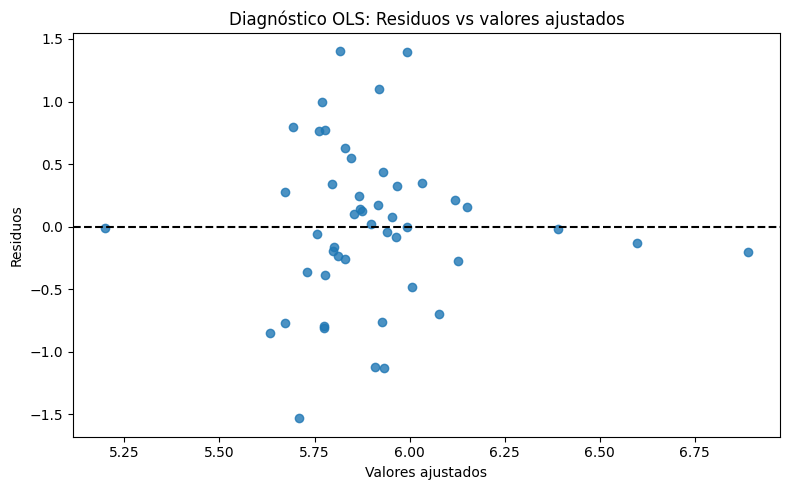

In [122]:
# ===============================
# PART 3.2 — DIAGNÓSTICO: RESIDUOS VS AJUSTADOS
# ===============================

ols_df["fitted_values"] = ols_los.fittedvalues
ols_df["residuals"] = ols_los.resid
ols_df["standardized_residuals"] = ols_los.get_influence().resid_studentized_internal

plt.figure(figsize=(8, 5))
plt.scatter(
    ols_df["fitted_values"],
    ols_df["residuals"],
    alpha=0.8
)

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Diagnóstico OLS: Residuos vs valores ajustados")
plt.tight_layout()
plt.show()

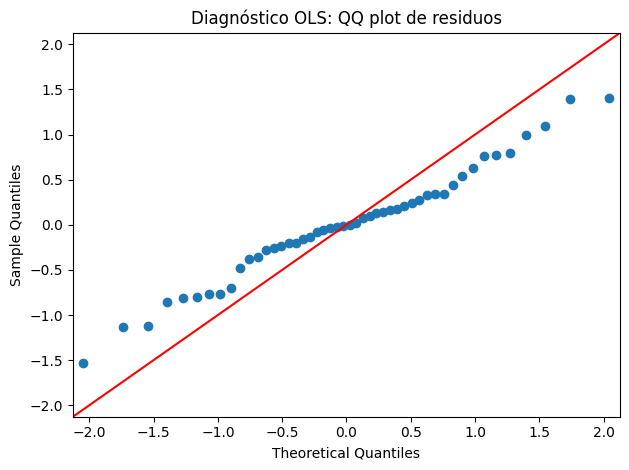

In [123]:
# ===============================
# PART 3.3 — QQ PLOT DE RESIDUOS
# ===============================

sm.qqplot(ols_los.resid, line="45")
plt.title("Diagnóstico OLS: QQ plot de residuos")
plt.tight_layout()
plt.show()

In [124]:
# ===============================
# RESIDUOS EXTREMOS
# ===============================

residual_outliers = ols_df[
    [
        "codigo_comuna",
        "nombre_comuna_final",
        "grd_mean_los",
        "fitted_values",
        "residuals",
        "standardized_residuals"
    ]
].copy()

residual_outliers["abs_standardized_residuals"] = residual_outliers["standardized_residuals"].abs()

residual_outliers = residual_outliers.sort_values(
    "abs_standardized_residuals",
    ascending=False
)

display(residual_outliers.head(10))

,codigo_comuna,nombre_comuna_final,grd_mean_los,fitted_values,residuals,standardized_residuals,abs_standardized_residuals
33,13202,Pirque,4.176776,5.709482,-1.532706,-2.397250,2.397250
39,13403,Calera de Tango,7.220000,5.817525,1.402475,2.221976,2.221976
3,13102,Cerrillos,7.390000,5.992160,1.397840,2.215120,2.215120
1,5102,Casablanca,4.800000,5.933926,-1.133926,-1.862536,1.862536
32,13201,Puente Alto,4.784390,5.908262,-1.123872,-1.759889,1.759889
18,13119,maipu,7.020000,5.920368,1.099632,1.719812,1.719812
15,13116,Lo Espejo,6.763143,5.770484,0.992659,1.524042,1.524042
45,13505,San Pedro,4.900369,5.672682,-0.772313,-1.371423,1.371423
44,13504,María Pinto,4.780000,5.632265,-0.852265,-1.322744,1.322744
30,13131,San Ramón,4.966448,5.774130,-0.807682,-1.260654,1.260654


### Comunas con residuos extremos

La tabla de residuos identifica las comunas donde el modelo predice peor la estadía hospitalaria promedio. Pirque presenta el mayor residuo negativo estandarizado. Esto significa que su estadía observada es menor que la predicha por el modelo. En cambio, Calera de Tango y Cerrillos presentan residuos positivos elevados, lo que indica que su estadía hospitalaria promedio observada es mayor que la esperada según las covariables incluidas.

Estos residuos sugieren que existen características locales no capturadas por el modelo. Por ejemplo, diferencias en composición diagnóstica, severidad de los casos, acceso a hospitales, patrones de derivación o características de la red asistencial podrían explicar por qué algunas comunas se alejan de las predicciones.

Los residuos estandarizados más altos se ubican en torno a 2.2 a 2.4 en valor absoluto. Esto indica la presencia de observaciones influyentes, pero no necesariamente errores de datos. Por esta razón, se mantienen en el análisis y se interpretan como posibles diferencias territoriales reales.

## Revisión adicional con errores robustos HC3

Como el número de comunas es reducido y los diagnósticos muestran algunas observaciones influyentes, se estima una versión adicional del modelo OLS con errores estándar robustos HC3.

Esta estimación no cambia los coeficientes del modelo, pero ajusta los errores estándar para que la inferencia sea menos sensible a problemas de heterocedasticidad o influencia de observaciones extremas.

In [146]:

# OLS CON ERRORES ROBUSTOS HC3
# ===============================

ols_los_robust = ols_los.get_robustcov_results(cov_type="HC3")

print(ols_los_robust.summary())

                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     5.328
Date:                Mon, 04 May 2026   Prob (F-statistic):            0.00142
Time:                        01:57:40   Log-Likelihood:                -45.715
No. Observations:                  48   AIC:                             101.4
Df Residuals:                      43   BIC:                             110.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     5.08

In [147]:
# ===============================
# TABLA OLS ROBUSTA
# ===============================

robust_results = pd.DataFrame({
    "coef": ols_los_robust.params,
    "std_err_HC3": ols_los_robust.bse,
    "t_value": ols_los_robust.tvalues,
    "p_value": ols_los_robust.pvalues,
    "ci_low_95": ols_los_robust.conf_int()[:, 0],
    "ci_high_95": ols_los_robust.conf_int()[:, 1]
}, index=ols_los.params.index)

display(robust_results)

,coef,std_err_HC3,t_value,p_value,ci_low_95,ci_high_95
const,5.086597,3.054278,1.665401,0.103103,-1.072941,11.246136
pct_foreign_10pp,0.154070,0.155782,0.989013,0.328190,-0.160094,0.468235
schooling_gap,0.017943,0.260423,0.068898,0.945390,-0.507250,0.543135
pct_unemployed_10pp,0.486424,0.533466,0.911819,0.366948,-0.589412,1.562261
dependency_ratio_10pp,-0.246806,0.292415,-0.844026,0.403326,-0.836516,0.342905


### Interpretación de errores robustos

La estimación con errores robustos HC3 mantiene las mismas conclusiones sustantivas del modelo OLS original. Ninguna covariable alcanza significancia estadística al 5%.

El coeficiente de `pct_foreign_10pp` sigue siendo positivo, pero no significativo. Esto indica que, aunque la dirección de la asociación entre proporción extranjera y estadía hospitalaria promedio es positiva, la evidencia estadística no es suficiente para afirmar una relación clara.

La revisión robusta confirma que la Parte 3 debe interpretarse como un análisis exploratorio. Las covariables comunales incluidas no explican de manera fuerte la variación en `grd_mean_los`, y probablemente faltan variables clínicas o institucionales más directamente relacionadas con la duración de la hospitalización.

In [128]:
# ===============================
# GUARDAR RESULTADOS PARTE 3
# ===============================

os.makedirs("output", exist_ok=True)

ols_results.to_csv("output/ols_grd_mean_los_results.csv")
robust_results.to_csv("output/ols_grd_mean_los_robust_results.csv")
residual_outliers.to_csv("output/ols_grd_mean_los_residual_outliers.csv", index=False)

print("Resultados de Parte 3 guardados en output/")

Resultados de Parte 3 guardados en output/


In [129]:
display(ols_results)
print("R2:", ols_los.rsquared)
print("R2 ajustado:", ols_los.rsquared_adj)
display(residual_outliers.head(10))

,coef,std_err,t_value,p_value,ci_low_95,ci_high_95
const,5.086597,3.240948,1.569478,0.123867,-1.449396,11.622591
pct_foreign_10pp,0.154070,0.151207,1.018938,0.313931,-0.150867,0.459008
schooling_gap,0.017943,0.191309,0.093789,0.925712,-0.367868,0.403754
pct_unemployed_10pp,0.486424,0.687598,0.707425,0.483119,-0.900250,1.873098
dependency_ratio_10pp,-0.246806,0.262754,-0.939302,0.352823,-0.776700,0.283089


R2: 0.13389263514870442
R2 ajustado: 0.05332450818579326


,codigo_comuna,nombre_comuna_final,grd_mean_los,fitted_values,residuals,standardized_residuals,abs_standardized_residuals
33,13202,Pirque,4.176776,5.709482,-1.532706,-2.397250,2.397250
39,13403,Calera de Tango,7.220000,5.817525,1.402475,2.221976,2.221976
3,13102,Cerrillos,7.390000,5.992160,1.397840,2.215120,2.215120
1,5102,Casablanca,4.800000,5.933926,-1.133926,-1.862536,1.862536
32,13201,Puente Alto,4.784390,5.908262,-1.123872,-1.759889,1.759889
18,13119,maipu,7.020000,5.920368,1.099632,1.719812,1.719812
15,13116,Lo Espejo,6.763143,5.770484,0.992659,1.524042,1.524042
45,13505,San Pedro,4.900369,5.672682,-0.772313,-1.371423,1.371423
44,13504,María Pinto,4.780000,5.632265,-0.852265,-1.322744,1.322744
30,13131,San Ramón,4.966448,5.774130,-0.807682,-1.260654,1.260654


## Resumen Parte 3

La Parte 3 analiza la estadía hospitalaria promedio como resultado continuo a nivel comunal. El modelo OLS permite evaluar si variables como migración, brecha educacional, desempleo imputado y razón de dependencia se asocian con diferencias en los días promedio de hospitalización.

Los resultados muestran que el modelo tiene bajo poder explicativo. El R² es 0.134 y el R² ajustado es 0.053, lo que indica que la mayor parte de la variación comunal en `grd_mean_los` queda sin explicar por las covariables incluidas.

Ninguna variable resulta estadísticamente significativa al 5%, tanto en el modelo OLS estándar como en la versión con errores robustos HC3. Esto sugiere que la duración promedio de hospitalización depende probablemente de otros factores no incluidos, como severidad clínica, diagnóstico principal, edad de los pacientes, disponibilidad hospitalaria y patrones de derivación.

En este contexto, el modelo OLS funciona como una herramienta exploratoria para identificar patrones comunales, más que como evidencia causal sobre duración individual de hospitalización. Al igual que en las partes anteriores, los resultados deben interpretarse como asociaciones ecológicas a nivel comunal.

# Part 4: Ecological Fallacy

Este análisis es ecológico porque la unidad de observación no es la persona, sino la comuna. Esto significa que las variables del Censo, ENO y GRD fueron agregadas a nivel comunal y luego vinculadas mediante `codigo_comuna`. Por lo tanto, los modelos no comparan directamente personas chilenas y extranjeras, ni siguen a individuos específicos entre datasets. Lo que se observa son diferencias entre comunas con distintas características demográficas y distintos resultados de salud.

Una asociación individual se refiere a una relación medida directamente entre personas. Por ejemplo, una pregunta individual sería: “¿una persona nacida en el extranjero tiene mayor probabilidad de presentar una notificación ENO que una persona chilena, controlando por edad, sexo y otras características?”. En cambio, una asociación ecológica pregunta algo distinto: “¿las comunas con mayor proporción de población extranjera presentan mayores tasas de notificación ENO?”. Esta segunda pregunta puede ser útil, pero no permite concluir automáticamente lo primero.

Un ejemplo claro aparece en el modelo Binomial Negativo para ENO. La variable `pct_foreign_10pp` presenta un IRR de aproximadamente 1.54, lo que sugiere que, manteniendo constantes las demás variables del modelo, un aumento de 10 puntos porcentuales en la proporción de población extranjera de una comuna se asocia con una tasa esperada de notificaciones ENO cerca de 54% mayor. Una interpretación incorrecta sería decir: “las personas extranjeras tienen 54% más riesgo de ser notificadas por ENO”. Esa afirmación sería una falacia ecológica, porque el modelo no observa riesgos individuales, sino tasas agregadas por comuna. La asociación podría deberse a muchas otras características comunales: mayor densidad poblacional, mayor acceso a diagnóstico, mejor capacidad de vigilancia epidemiológica, concentración de servicios de salud o mayor movilidad urbana.

A pesar de esta limitación, la asociación ecológica sigue siendo útil para planificación en salud pública. Por ejemplo, si comunas con mayor proporción de población extranjera, como Santiago o Independencia, presentan tasas ENO más altas, eso puede orientar decisiones territoriales: reforzar campañas de prevención, mejorar acceso a información sanitaria, aumentar disponibilidad de testeo o focalizar recursos en comunas con mayor demanda potencial. En este sentido, el análisis no permite afirmar que una persona extranjera tenga mayor riesgo individual, pero sí ayuda a identificar territorios donde podrían requerirse intervenciones más intensivas o culturalmente adaptadas.

Otro ejemplo aparece en GRD. En el modelo Binomial Negativo para egresos hospitalarios, ninguna covariable alcanza significancia estadística al 5%. Esto muestra que la composición migratoria comunal no parece explicar claramente las tasas de egresos hospitalarios una vez consideradas las demás covariables. Sin embargo, algunas comunas como Cerro Navia, Melipilla o Renca aparecen con tasas GRD elevadas. Esto puede ser útil para detectar territorios con mayor uso hospitalario, pero no permite concluir que sus habitantes tengan necesariamente mayor riesgo individual de enfermedad.

Una amenaza adicional a la inferencia es la omisión de variables relevantes. Los modelos no incorporan directamente disponibilidad de hospitales, capacidad de atención primaria, pobreza, hacinamiento, densidad poblacional, estructura etaria detallada ni patrones de derivación. También existe posible error de medición en ENO debido a registros con comuna anonimizada, lo que puede subestimar las tasas comunales. Además, el análisis usa un número reducido de comunas, por lo que los valores-p deben interpretarse con cautela. En trabajos futuros sería recomendable incorporar controles territoriales adicionales, analizar autocorrelación espacial y evaluar la sensibilidad de los resultados frente a registros faltantes o comunas con denominadores pequeños.

# Part 5: Spatial Visualization of Model Output

En esta sección se visualizan espacialmente los resultados del modelo principal para ENO. Como en la Parte 2 se detectó una sobredispersión severa en los conteos, se utiliza el modelo Binomial Negativo como modelo principal.

El objetivo es transformar los resultados estadísticos en una lectura territorial. Para ello, se construyen dos mapas: uno con la tasa ENO predicha por el modelo y otro con los residuos Pearson. Además, se presenta un coefficient plot en formato IRR para resumir la dirección, magnitud e incertidumbre de las covariables del modelo.

La visualización espacial es útil porque permite identificar comunas donde el modelo predice tasas más altas y comunas donde las notificaciones observadas son mayores o menores que lo esperado.

In [130]:
# ===============================
# PART 5.0 — PREDICCIONES Y RESIDUOS DEL MODELO ENO
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Modelo principal ENO
# Como hubo sobredispersión fuerte, usamos Binomial Negativo
primary_eno_model = nb_eno
primary_eno_name = "Negative Binomial"

# Copia para no alterar accidentalmente
map_model_df = count_df.copy()

# Predicción de conteos ENO
map_model_df["predicted_eno_total"] = primary_eno_model.predict(
    X_eno,
    offset=offset_eno
)

# Tasa predicha por 10.000 habitantes
map_model_df["predicted_eno_rate_per_10k"] = (
    map_model_df["predicted_eno_total"] / map_model_df["pop_total"]
) * 10000

# Residuos Pearson
map_model_df["pearson_resid"] = primary_eno_model.resid_pearson

display(map_model_df[[
    "codigo_comuna",
    "nombre_comuna_final",
    "pop_total",
    "eno_total",
    "predicted_eno_total",
    "predicted_eno_rate_per_10k",
    "pearson_resid"
]].head())

print("Modelo usado para mapas:", primary_eno_name)
print("Comunas con predicción:", map_model_df.shape[0])

,codigo_comuna,nombre_comuna_final,pop_total,eno_total,predicted_eno_total,predicted_eno_rate_per_10k,pearson_resid
0,5101,Valparaíso,284938.0,4821,1903.690834,66.810704,1.532047
1,5102,Casablanca,29876.0,312,292.132778,97.781757,0.067891
2,13101,Santiago,435385.0,12186,6975.368329,160.211499,0.746951
3,13102,Cerrillos,85041.0,642,1181.932961,138.983897,-0.456629
4,13103,Cerro Navia,126140.0,1002,1179.375243,93.497324,-0.150334


Modelo usado para mapas: Negative Binomial
Comunas con predicción: 48


## Parte 5.0: Predicciones y residuos del modelo ENO

A partir del modelo Binomial Negativo para ENO se calcularon los conteos predichos de notificaciones para cada comuna. Luego, estos conteos se transformaron en tasas predichas por cada 10.000 habitantes usando `pop_total` como denominador.

También se calcularon los residuos Pearson. Estos residuos comparan las notificaciones observadas con las notificaciones predichas por el modelo. Un residuo positivo indica que la comuna tuvo más notificaciones ENO que las esperadas según sus covariables. Un residuo negativo indica que la comuna tuvo menos notificaciones que las predichas por el modelo.

El modelo genera predicciones para 48 comunas, que corresponden a las comunas utilizadas en los modelos de conteo después de eliminar filas con valores faltantes en las covariables.

In [131]:
# ===============================
#  — CARGAR SHAPEFILE DE COMUNAS
# ===============================

import geopandas as gpd
import shutil

# Crear carpeta ordenada
os.makedirs("shape_fixed", exist_ok=True)

# Copiar archivos con un mismo nombre base
rename_map = {
    "comunas (1).shp": "shape_fixed/comunas.shp",
    "comunas.shx": "shape_fixed/comunas.shx",
    "comunas.dbf": "shape_fixed/comunas.dbf",
    "comunas.prj": "shape_fixed/comunas.prj",
    "comunas.CPG": "shape_fixed/comunas.CPG",
    "comunas.sbn": "shape_fixed/comunas.sbn",
    "comunas (1).sbx": "shape_fixed/comunas.sbx"
}

for src, dst in rename_map.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        print("Copiado:", src, "->", dst)
    else:
        print("No encontrado:", src)

# Leer shapefile
comunas_gdf = gpd.read_file("shape_fixed/comunas.shp")

print("Shape del shapefile:", comunas_gdf.shape)
print("Columnas del shapefile:")
print(comunas_gdf.columns.tolist())

display(comunas_gdf.head())

Copiado: comunas (1).shp -> shape_fixed/comunas.shp
Copiado: comunas.shx -> shape_fixed/comunas.shx
Copiado: comunas.dbf -> shape_fixed/comunas.dbf
Copiado: comunas.prj -> shape_fixed/comunas.prj
Copiado: comunas.CPG -> shape_fixed/comunas.CPG
Copiado: comunas.sbn -> shape_fixed/comunas.sbn
Copiado: comunas (1).sbx -> shape_fixed/comunas.sbx
Shape del shapefile: (346, 12)
Columnas del shapefile:
['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-7992818.789 -4056669.319, -7992731...."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-7831651.813 -4022443.109, -7831596...."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-7892616.357 -4060673.364, -7892621...."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-7906457.717 -4051723.734, -7906266...."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-8121756.186 -4645860.295, -8121644...."


In [132]:
# ===============================
#  — DETECTAR COLUMNA DE CÓDIGO DE COMUNA
# ===============================

possible_code_cols = [
    "codigo_comuna", "CODIGO_COMUNA", "cod_comuna", "COD_COMUNA",
    "CUT_COM", "cut_com", "CUT", "cut",
    "COMUNA", "comuna", "CODIGO", "codigo",
    "ID_COMUNA", "id_comuna"
]

codigo_col = None

for col in possible_code_cols:
    if col in comunas_gdf.columns:
        codigo_col = col
        break

print("Columna detectada como código de comuna:", codigo_col)

if codigo_col is None:
    print("No se detectó automáticamente. Revisa estas columnas:")
    print(comunas_gdf.columns.tolist())
else:
    comunas_gdf[codigo_col] = pd.to_numeric(comunas_gdf[codigo_col], errors="coerce")
    display(comunas_gdf[[codigo_col]].head())

Columna detectada como código de comuna: cod_comuna


,cod_comuna
0,6204
1,6102
2,6103
3,6104
4,9121


In [133]:
# ===============================
#  — MERGE GEODATAFRAME + RESULTADOS DEL MODELO
# ===============================

map_values = map_model_df[[
    "codigo_comuna",
    "nombre_comuna_final",
    "eno_total",
    "predicted_eno_total",
    "predicted_eno_rate_per_10k",
    "pearson_resid"
]].copy()

map_values["codigo_comuna"] = pd.to_numeric(map_values["codigo_comuna"], errors="coerce")

map_df = comunas_gdf.merge(
    map_values,
    left_on=codigo_col,
    right_on="codigo_comuna",
    how="left"
)

print("Total geometrías:", map_df.shape[0])
print("Comunas con datos del modelo:", map_df["predicted_eno_rate_per_10k"].notna().sum())

display(
    map_df[[
        "codigo_comuna",
        "nombre_comuna_final",
        "predicted_eno_rate_per_10k",
        "pearson_resid"
    ]]
    .dropna()
    .head()
)

Total geometrías: 346
Comunas con datos del modelo: 48


,codigo_comuna,nombre_comuna_final,predicted_eno_rate_per_10k,pearson_resid
36,13130.0,San Miguel,112.834701,-0.266025
47,13131.0,San Ramón,64.504768,0.400920
57,13108.0,Independencia,303.064721,-0.536623
61,13109.0,La Reina,106.504257,-0.349962
68,13122.0,Quilicura,57.313363,0.097110


## 5.1 Predicted-rate map

Para construir los mapas se utilizó un shapefile de comunas de Chile. La columna detectada como identificador comunal fue `cod_comuna`, que se unió con `codigo_comuna` de la tabla de resultados del modelo.

El shapefile contiene 346 geometrías comunales, mientras que el modelo tiene resultados para 48 comunas. Por eso, algunas comunas aparecen sin datos en la unión espacial. Esto es esperable, ya que el shapefile cubre todo Chile y el análisis se concentra en el conjunto comunal disponible para la tarea.

Aunque el pool analítico incluye algunas comunas fuera de la Región Metropolitana, los mapas finales se muestran solo para la RM con el fin de mejorar la legibilidad visual.

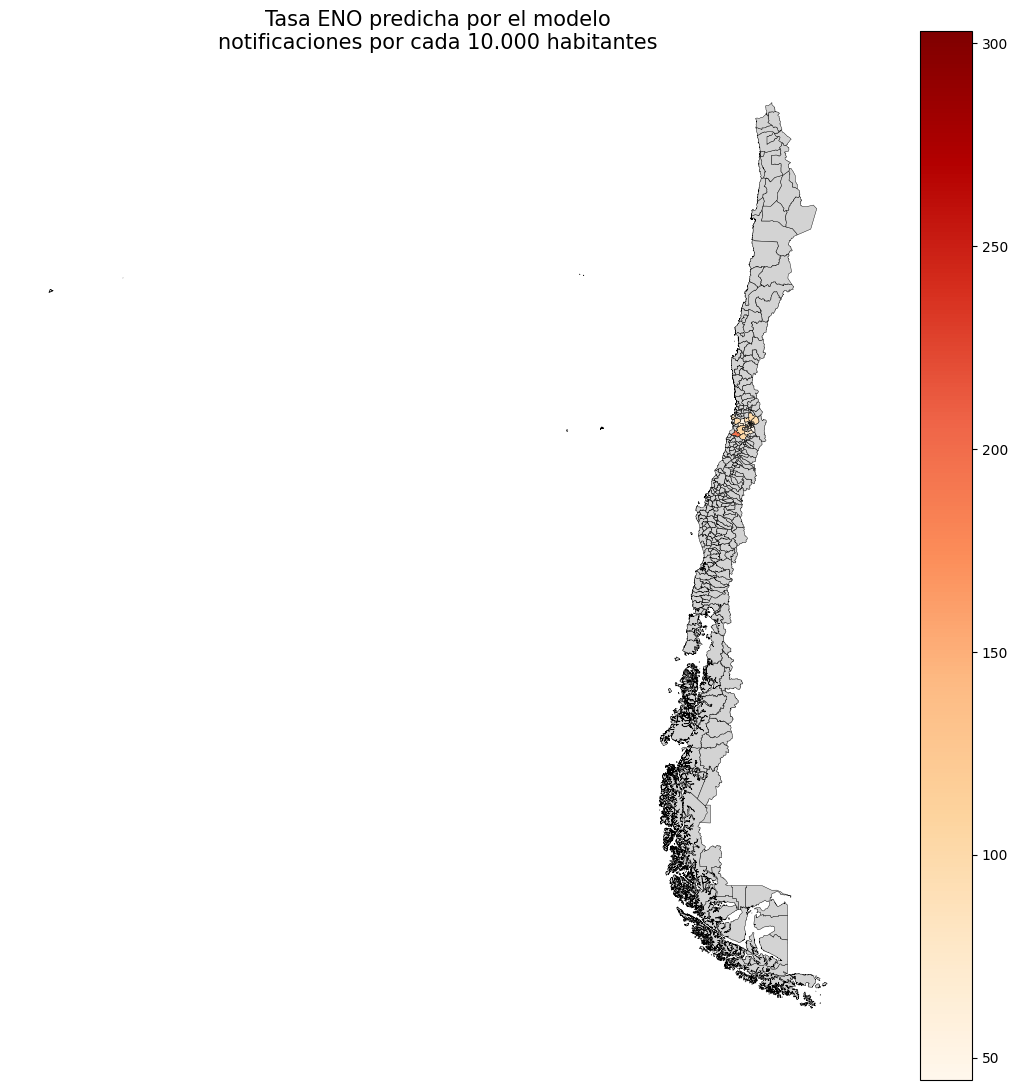

In [134]:
# ===============================
#  — MAPA DE TASA ENO PREDICHA
# ===============================

fig, ax = plt.subplots(figsize=(11, 11))

map_df.plot(
    column="predicted_eno_rate_per_10k",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    }
)

ax.set_title(
    "Tasa ENO predicha por el modelo\nnotificaciones por cada 10.000 habitantes",
    fontsize=15
)

ax.axis("off")
plt.tight_layout()

os.makedirs("output", exist_ok=True)
plt.savefig("output/map_predicted_eno_rate.png", dpi=300, bbox_inches="tight")

plt.show()

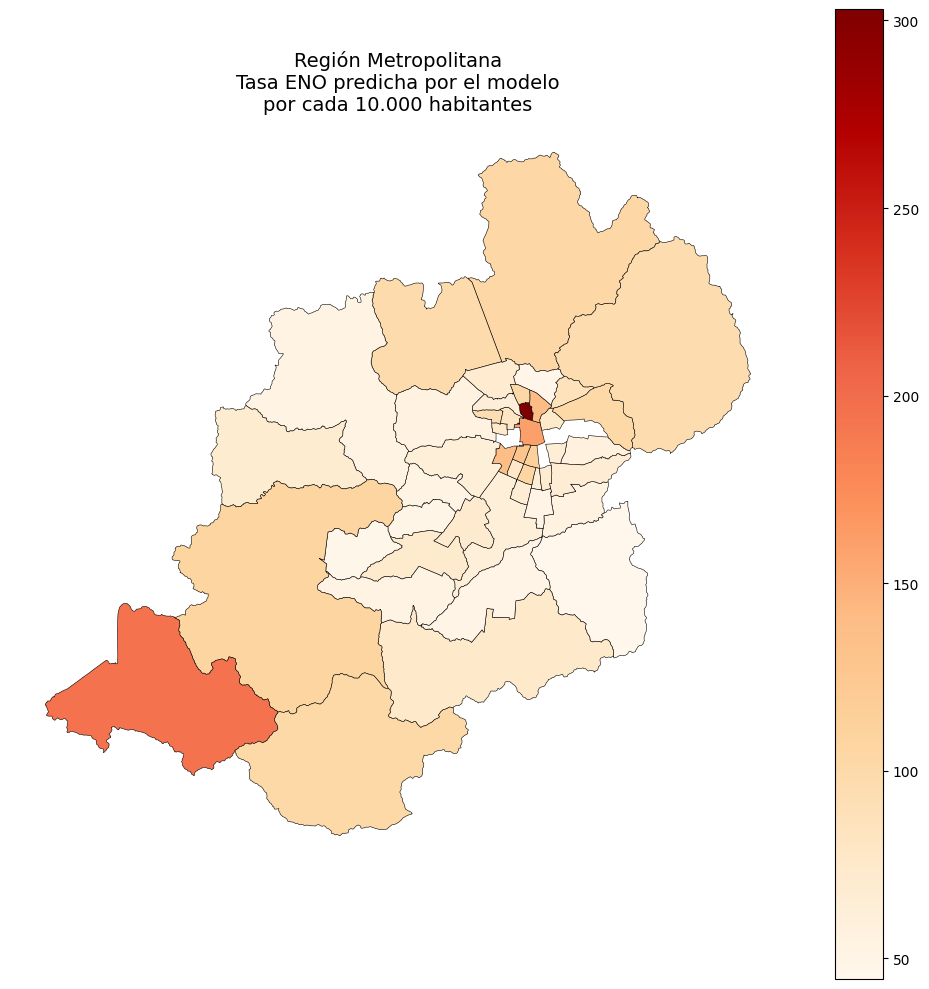

In [ ]:
# ===============================
# MAPA RM — TASA ENO PREDICHA
# ===============================

fig, ax = plt.subplots(figsize=(10, 10))

map_df_rm.plot(
    column="predicted_eno_rate_per_10k",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    }
)

ax.set_title(
    "Región Metropolitana\nTasa ENO predicha por el modelo\npor cada 10.000 habitantes",
    fontsize=14
)

ax.axis("off")
plt.tight_layout()

plt.savefig("output/map_rm_predicted_eno_rate.png", dpi=300, bbox_inches="tight")
plt.show()

### Mapa de tasa ENO predicha

El mapa de tasa ENO predicha muestra la distribución territorial de las notificaciones esperadas según el modelo Binomial Negativo. Los tonos más intensos representan comunas donde el modelo espera una mayor tasa de notificaciones por cada 10.000 habitantes.

Este mapa no corresponde directamente a las tasas observadas, sino a las tasas estimadas por el modelo a partir de las covariables incluidas: proporción de población extranjera, brecha educacional, desempleo imputado y razón de dependencia.

En los resultados del modelo, algunas comunas metropolitanas presentan tasas predichas especialmente altas. Por ejemplo, Independencia aparece con una tasa predicha elevada, lo que es coherente con su alta proporción de población extranjera. Santiago también presenta una tasa predicha alta, lo que refleja su peso demográfico y su perfil urbano. Sin embargo, estas predicciones deben interpretarse como patrones territoriales esperados, no como riesgos individuales.

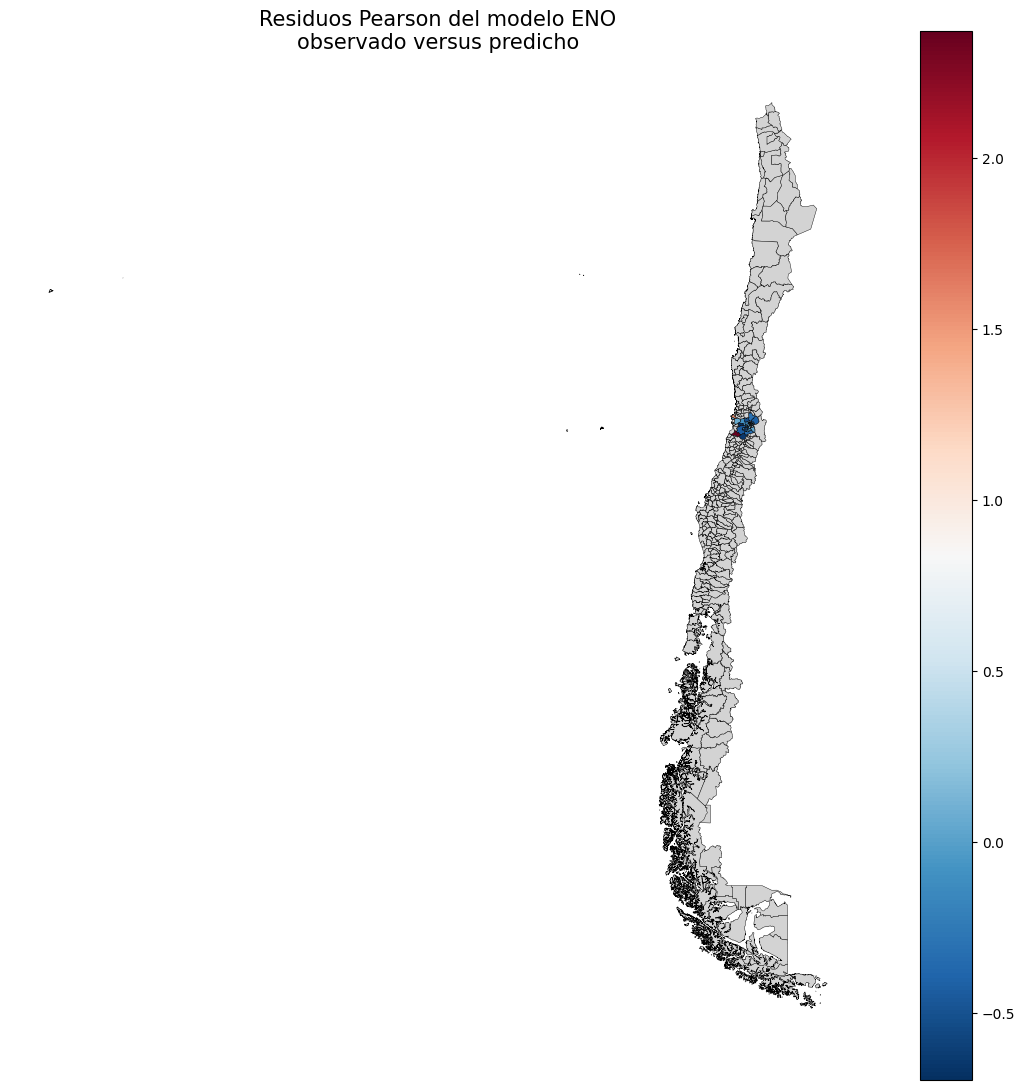

In [135]:
# ===============================
# — MAPA DE RESIDUOS PEARSON
# ===============================

fig, ax = plt.subplots(figsize=(11, 11))

map_df.plot(
    column="pearson_resid",
    cmap="RdBu_r",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    }
)

ax.set_title(
    "Residuos Pearson del modelo ENO\nobservado versus predicho",
    fontsize=15
)

ax.axis("off")
plt.tight_layout()

plt.savefig("output/map_eno_pearson_residuals.png", dpi=300, bbox_inches="tight")

plt.show()

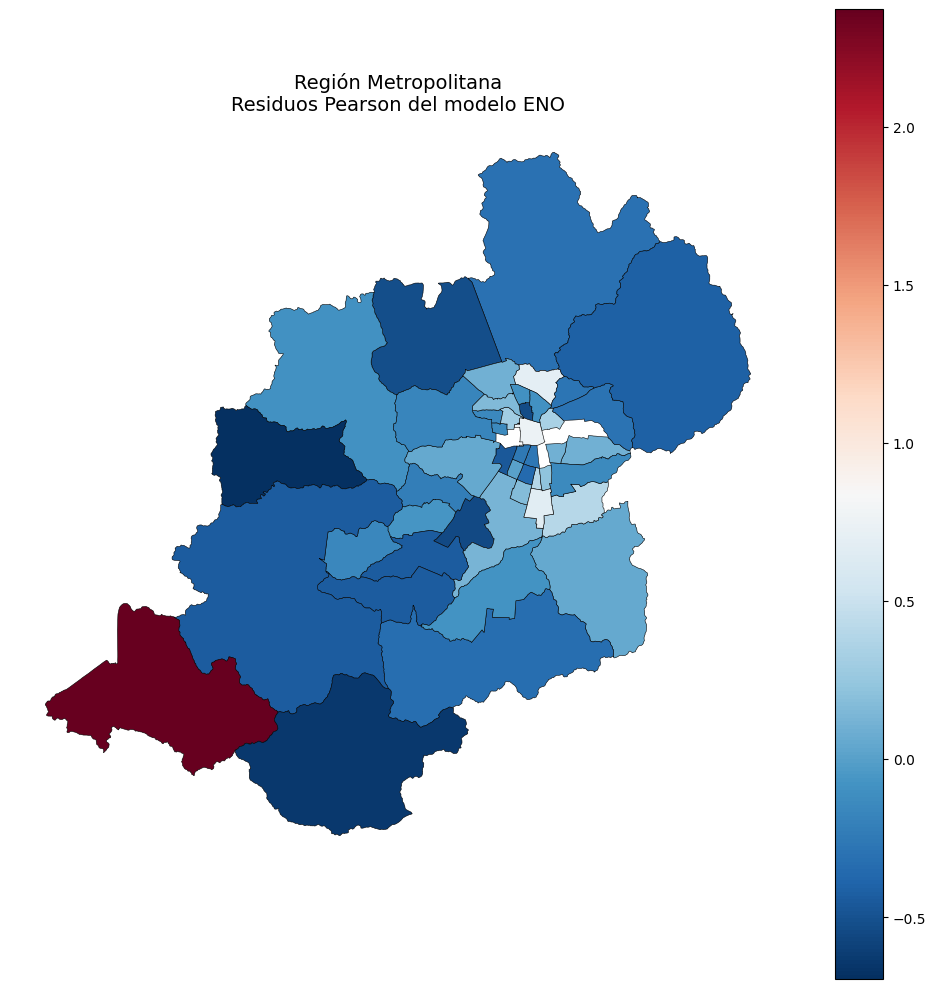

In [ ]:
# ===============================
# MAPA RM — RESIDUOS PEARSON
# ===============================

fig, ax = plt.subplots(figsize=(10, 10))

map_df_rm.plot(
    column="pearson_resid",
    cmap="RdBu_r",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    }
)

ax.set_title(
    "Región Metropolitana\nResiduos Pearson del modelo ENO",
    fontsize=14
)

ax.axis("off")
plt.tight_layout()

plt.savefig("output/map_rm_eno_pearson_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

### Mapa de residuos Pearson

El mapa de residuos Pearson muestra dónde el modelo predice mejor o peor las notificaciones ENO. Los residuos positivos indican comunas con más notificaciones observadas que las esperadas por el modelo, mientras que los residuos negativos indican comunas con menos notificaciones observadas que las predichas.

En la Región Metropolitana, comunas como Santiago, Huechuraba, La Pintana, Puente Alto y San Ramón aparecen entre las comunas con residuos positivos. Esto sugiere que el modelo subestima sus notificaciones ENO, es decir, estas comunas presentan más casos observados de los que se esperarían según las covariables incluidas.

Por otro lado, comunas como Independencia, Lampa, Cerrillos, Melipilla, Isla de Maipo, Talagante y Lo Barnechea aparecen con residuos negativos. Esto indica que el modelo predice más notificaciones de las que realmente se observan. Estos residuos pueden reflejar factores no incluidos en el modelo, como diferencias en acceso a diagnóstico, vigilancia epidemiológica, brotes locales, subregistro o características específicas de la red de salud.

In [136]:
# ===============================
# — COMUNAS CON MAYORES RESIDUOS
# ===============================

residual_table = map_model_df[[
    "codigo_comuna",
    "nombre_comuna_final",
    "eno_total",
    "predicted_eno_total",
    "predicted_eno_rate_per_10k",
    "pearson_resid"
]].copy()

residual_table["abs_pearson_resid"] = residual_table["pearson_resid"].abs()

print("Mayores residuos positivos:")
display(
    residual_table
    .sort_values("pearson_resid", ascending=False)
    .head(10)
)

print("Mayores residuos negativos:")
display(
    residual_table
    .sort_values("pearson_resid", ascending=True)
    .head(10)
)

residual_table.to_csv("output/eno_model_residuals.csv", index=False)

Mayores residuos positivos:


,codigo_comuna,nombre_comuna_final,eno_total,predicted_eno_total,predicted_eno_rate_per_10k,pearson_resid,abs_pearson_resid
45,13505,San Pedro,731,216.377836,194.794595,2.372873,2.372873
0,5101,Valparaíso,4821,1903.690834,66.810704,1.532047,1.532047
2,13101,Santiago,12186,6975.368329,160.211499,0.746951,0.746951
7,13107,Huechuraba,832,491.045655,48.232521,0.693638,0.693638
12,13112,La Pintana,1507,903.112634,51.482584,0.668303,0.668303
32,13201,Puente Alto,4334,3092.298904,54.781663,0.401481,0.401481
30,13131,San Ramón,687,490.249139,64.504768,0.400920,0.400920
22,13123,Providencia,1455,1089.048293,75.642011,0.335875,0.335875
25,13126,Quinta Normal,1361,1046.542569,80.907188,0.300329,0.300329
11,13111,La Granja,943,771.741339,68.891944,0.221768,0.221768


Mayores residuos negativos:


,codigo_comuna,nombre_comuna_final,eno_total,predicted_eno_total,predicted_eno_rate_per_10k,pearson_resid,abs_pearson_resid
44,13504,María Pinto,32,106.457105,69.344128,-0.696147,0.696147
42,13502,Alhué,28,78.594645,101.177452,-0.639685,0.639685
39,13403,Calera de Tango,84,184.084811,72.215610,-0.542218,0.542218
8,13108,Independencia,1642,3544.129765,303.064721,-0.536623,0.536623
36,13302,Lampa,672,1415.377652,97.504661,-0.525030,0.525030
3,13102,Cerrillos,642,1181.932961,138.983897,-0.456629,0.456629
41,13501,Melipilla,824,1469.175585,107.770078,-0.438992,0.438992
48,13603,Isla de Maipo,115,205.108833,52.225094,-0.438255,0.438255
46,13601,Talagante,314,556.817946,72.854276,-0.435690,0.435690
14,13115,Lo Barnechea,630,1077.450259,95.671307,-0.415094,0.415094


## 5.2 Residual map

La tabla de residuos permite identificar las comunas donde el modelo se equivoca más. A nivel general del pool, San Pedro presenta el mayor residuo positivo, con un residuo Pearson de aproximadamente 2.37. Esto indica que sus notificaciones observadas son bastante mayores que las predichas por el modelo. Valparaíso también presenta un residuo positivo alto, seguido por Santiago, Huechuraba y La Pintana.

Entre los residuos negativos, María Pinto, Alhué, Calera de Tango, Independencia y Lampa aparecen como comunas donde el modelo predice más notificaciones de las observadas. En estos casos, el modelo sobreestima la carga ENO esperada.

Estas diferencias no deben interpretarse automáticamente como errores. Pueden reflejar factores territoriales no observados, como intensidad de vigilancia, acceso al sistema de salud, subregistro, brotes locales, denominadores poblacionales pequeños o características epidemiológicas específicas de cada comuna.

## 5.3 Coefficient plot

El coefficient plot resume los resultados del modelo Binomial Negativo para ENO usando razones de tasas de incidencia (IRR). Cada punto representa el IRR estimado para una covariable y cada línea horizontal representa su intervalo de confianza al 95%.

La línea vertical en IRR = 1 marca la ausencia de asociación. Valores a la derecha de 1 indican una asociación positiva con la tasa esperada de notificaciones ENO, mientras que valores a la izquierda de 1 indicarían una asociación negativa.

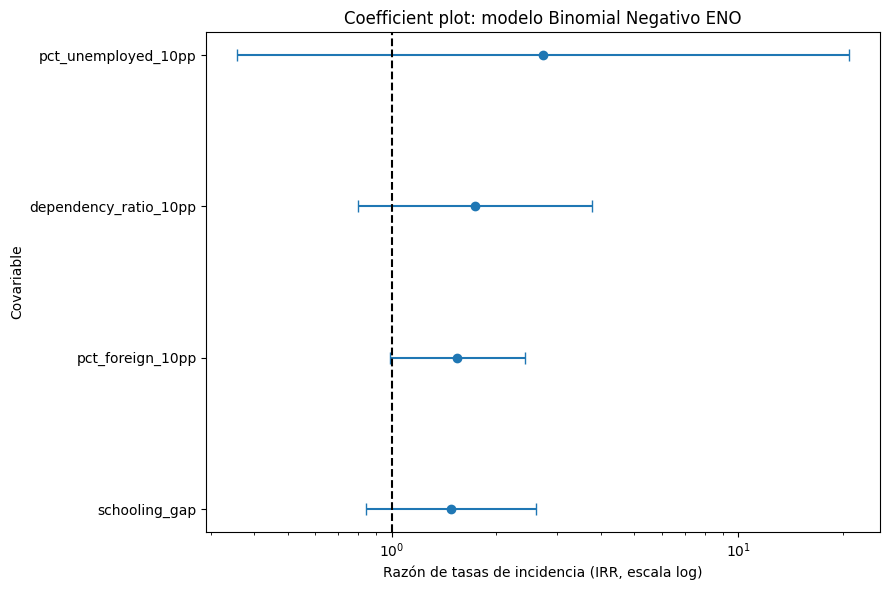

In [148]:
# ===============================
# PART 5.3 — COEFFICIENT PLOT / FOREST PLOT CORREGIDO
# ===============================

coef_plot = nb_eno_irr.drop(index="const").copy()
coef_plot = coef_plot.sort_values("IRR")

plt.figure(figsize=(9, 6))

plt.errorbar(
    coef_plot["IRR"],
    coef_plot.index,
    xerr=[
        coef_plot["IRR"] - coef_plot["IRR_low_95"],
        coef_plot["IRR_high_95"] - coef_plot["IRR"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(1, linestyle="--", color="black")
plt.xscale("log")
plt.xlabel("Razón de tasas de incidencia (IRR, escala log)")
plt.ylabel("Covariable")
plt.title("Coefficient plot: modelo Binomial Negativo ENO")
plt.tight_layout()

plt.savefig("output/eno_nb_coefficient_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretación del coefficient plot

El coefficient plot muestra que todas las covariables del modelo ENO tienen IRR mayores que 1 en el modelo Binomial Negativo. Esto indica asociaciones positivas con la tasa esperada de notificaciones ENO.

La asociación más clara corresponde a `pct_foreign_10pp`, con un IRR de 1.54. Esto sugiere que un aumento de 10 puntos porcentuales en la proporción de población extranjera se asocia con una tasa esperada de notificaciones ENO aproximadamente 54% mayor, manteniendo constantes las demás variables.

Sin embargo, el intervalo de confianza de `pct_foreign_10pp` incluye o se aproxima al valor nulo de 1, y su valor-p es 0.057. Por lo tanto, la evidencia debe interpretarse como sugerente, pero no concluyente al 5%.

Las demás covariables también presentan IRR mayores que 1, pero con intervalos de confianza amplios. Esto refleja incertidumbre estadística, consistente con el número reducido de comunas y con la heterogeneidad territorial del fenómeno.

## Resumen de la Parte 5

La Parte 5 transforma los resultados del modelo Binomial Negativo para ENO en visualizaciones espaciales y gráficas. El mapa de tasa predicha muestra dónde el modelo espera mayores tasas de notificación por cada 10.000 habitantes, mientras que el mapa de residuos Pearson identifica comunas donde las notificaciones observadas se alejan de lo esperado.

Los residuos positivos señalan comunas donde el modelo subestima la carga observada de ENO. Los residuos negativos muestran comunas donde el modelo sobreestima las notificaciones. Estas diferencias pueden deberse a factores no incluidos en el modelo, como acceso a diagnóstico, capacidad de vigilancia epidemiológica, brotes locales, subregistro o características específicas de la red asistencial.

El coefficient plot complementa los mapas mostrando la dirección e incertidumbre de las covariables. Aunque la proporción de población extranjera presenta una asociación positiva con ENO, la evidencia estadística no es concluyente al 5%. Por lo tanto, los resultados deben interpretarse como asociaciones ecológicas útiles para planificación territorial, pero no como evidencia causal individual.

In [138]:
# ===============================
# FILTRAR SOLO REGIÓN METROPOLITANA PARA MAPAS
# ===============================

# Asegurar que los códigos estén en formato numérico
map_df["codigo_comuna"] = pd.to_numeric(map_df["codigo_comuna"], errors="coerce")

# Crear versión string para filtrar por prefijo 13
map_df["codigo_comuna_str"] = map_df["codigo_comuna"].astype("Int64").astype(str)

# Filtrar solo comunas RM
map_df_rm = map_df[map_df["codigo_comuna_str"].str.startswith("13", na=False)].copy()

print("Total geometrías en map_df:", map_df.shape[0])
print("Total geometrías RM en map_df_rm:", map_df_rm.shape[0])
print("Comunas RM con datos del modelo:", map_df_rm["predicted_eno_rate_per_10k"].notna().sum())

display(
    map_df_rm[[
        "codigo_comuna",
        "nombre_comuna_final",
        "predicted_eno_rate_per_10k",
        "pearson_resid"
    ]].head(10)
)

Total geometrías en map_df: 346
Total geometrías RM en map_df_rm: 46
Comunas RM con datos del modelo: 46


,codigo_comuna,nombre_comuna_final,predicted_eno_rate_per_10k,pearson_resid
36,13130.0,San Miguel,112.834701,-0.266025
47,13131.0,San Ramón,64.504768,0.400920
57,13108.0,Independencia,303.064721,-0.536623
61,13109.0,La Reina,106.504257,-0.349962
68,13122.0,Quilicura,57.313363,0.097110
82,13123.0,Providencia,75.642011,0.335875
90,13403.0,Calera de Tango,72.215610,-0.542218
109,13301.0,Colina,103.898108,-0.300659
110,13101.0,Santiago,160.211499,0.746951
112,13302.0,Lampa,97.504661,-0.525030


# Parte 6: Síntesis integrada

El análisis integrado de Censo, ENO y GRD muestra que la composición demográfica de las comunas se relaciona con ciertos resultados de salud, pero de manera parcial y con alta heterogeneidad territorial. La tabla analítica final incluye 51 comunas del pool compartido, combinando información censal, notificaciones ENO y egresos hospitalarios GRD a nivel comunal. Aunque el foco principal es la Región Metropolitana, se mantuvieron algunas comunas fuera de RM porque formaban parte del conjunto oficial usado en la tarea.

Desde el punto de vista demográfico, las comunas presentan diferencias importantes en proporción de población extranjera, tamaño poblacional, brecha educacional y razón de dependencia. La matriz de correlación muestra que `pct_foreign` se asocia negativamente con `dependency_ratio_std` (-0.54), lo que sugiere que las comunas con mayor proporción de población extranjera tienden a tener menor razón de dependencia. Esto es coherente con la idea de que la población migrante suele concentrarse en edades laborales. También se observa una correlación positiva entre `pct_foreign` y `schooling_gap` (0.44), lo que indica que las diferencias educacionales entre población chilena y extranjera varían de forma relevante entre comunas.

En los resultados de salud, ENO parece estar más conectado con variables de migración y educación que GRD. En la Parte 1, `eno_rate_per_10k` mostró una correlación positiva con `schooling_gap` (0.34) y con `pct_foreign` (0.31). Esto sugiere que comunas con mayor proporción extranjera y mayores brechas educacionales tienden a presentar mayores tasas de notificación ENO. Sin embargo, esta relación no es uniforme. San Pedro aparece como el principal outlier ENO, con una tasa cercana a 658 notificaciones por cada 10.000 habitantes, probablemente influida por su bajo denominador poblacional. Santiago también destaca con una tasa cercana a 280 por cada 10.000 habitantes y con un volumen absoluto muy alto de notificaciones.

En GRD, el patrón es distinto. Las tasas de egresos hospitalarios parecen menos asociadas directamente a migración y más relacionadas con factores territoriales, socioeconómicos o del sistema de salud. Comunas como Cerro Navia y Melipilla presentan tasas GRD superiores a 2.100 egresos por cada 10.000 habitantes, lo que sugiere una mayor intensidad de uso hospitalario. Sin embargo, estas tasas no deben interpretarse como riesgo individual de enfermedad, sino como patrones territoriales de egresos hospitalarios.

Los modelos de regresión agregan información más allá de las correlaciones porque permiten controlar varias covariables simultáneamente y usar la población como offset. En los modelos de conteo, tanto ENO como GRD presentaron sobredispersión severa. El estadístico de dispersión fue 272.04 para ENO y 2917.18 para GRD, por lo que el modelo Poisson no fue adecuado como modelo principal. En ambos casos se reportó el modelo Binomial Negativo.

En el modelo Binomial Negativo para ENO, la variable más relevante fue `pct_foreign_10pp`, con un IRR de 1.54 y un valor-p de 0.057. Esto sugiere que un aumento de 10 puntos porcentuales en la proporción de población extranjera se asocia con una tasa esperada de notificaciones ENO aproximadamente 54% mayor, manteniendo constantes las demás covariables. Sin embargo, esta asociación no alcanza significancia estadística al 5%, por lo que debe interpretarse como una relación sugerente, no concluyente.

En el modelo Binomial Negativo para GRD, ninguna covariable resultó estadísticamente significativa al 5%. La variable con mayor IRR fue `pct_unemployed_10pp`, con un IRR de 3.76, pero con un intervalo de confianza muy amplio y un valor-p de 0.202. Esto sugiere que los egresos hospitalarios podrían depender de factores adicionales no incluidos en el modelo, como disponibilidad hospitalaria, composición diagnóstica, severidad clínica, estructura etaria más detallada, derivaciones o acceso a atención.

La Parte 3 refuerza esta idea. El modelo OLS para `grd_mean_los` tuvo un R² de 0.134 y un R² ajustado de 0.053, lo que indica que las covariables incluidas explican una proporción baja de la variación comunal en la estadía hospitalaria promedio. Ninguna variable fue significativa al 5%, incluso al usar errores estándar robustos HC3. Por lo tanto, la duración promedio de hospitalización parece depender de variables clínicas e institucionales más específicas que no están incluidas en esta tabla comunal.

Las visualizaciones espaciales ayudan a identificar patrones territoriales que los coeficientes no muestran por completo. El mapa de tasa ENO predicha permite observar dónde el modelo espera mayores tasas de notificación, mientras que el mapa de residuos Pearson muestra comunas donde las notificaciones observadas son mayores o menores que las predichas. Los residuos positivos indican comunas donde el modelo subestima las notificaciones observadas, mientras que los residuos negativos indican comunas donde el modelo las sobreestima. Esto sugiere que existen factores locales no observados, como vigilancia epidemiológica, acceso a diagnóstico, brotes específicos o subregistro.

En conjunto, el cruce entre Censo, ENO y GRD permite construir una historia integrada: la migración y la estructura demográfica se asocian con ciertos patrones de notificación ENO, pero no explican por sí solas los egresos hospitalarios ni la estadía promedio. Los modelos muestran que las correlaciones iniciales deben interpretarse con cautela, especialmente por la sobredispersión, el bajo número de comunas y la naturaleza ecológica del análisis.

La principal conclusión es que estos resultados son útiles para planificación territorial y generación de hipótesis, pero no permiten hacer afirmaciones causales a nivel individual. Las comunas con altas tasas observadas o altos residuos pueden ser priorizadas para análisis más detallados, campañas de prevención, revisión de acceso a diagnóstico o investigación de factores locales. Para futuros análisis sería recomendable incorporar variables de vivienda y servicios, pobreza, hacinamiento, densidad poblacional, infraestructura de salud, composición diagnóstica y estructura etaria más detallada.